<a href="https://colab.research.google.com/github/alphonsetandeta-hub/evolution-du-biomasse-dans-la-vallee-du-fluve-senegal/blob/main/01_etudes_data_finalc_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Notebook — Études & Analyses : data_finalc
**Projet** : Surveillance cultures blé & oignon — N'Diol & Fanaye  
**Auteur** : Responsable suivi télédétection — JSB Agriculture Intelligente  
**Données** : `data_finalc.xlsx` — 348 obs. · 36 variables · Jan–Avr 2026

---
### 🗺️ Contenu de ce notebook
| Section | Contenu |
|---------|----------|
| 1 | Imports & chargement des données |
| 2 | Exploration & statistiques descriptives |
| 3 | Analyses sol (Temp, Humidity, EC, pH, N, P, K, Salinity) |
| 4 | Analyses indices spectraux (NDVI, NDRE, SAVI, CIre, NDWI, LAI, FAPAR) |
| 5 | Analyses radar SAR (VV, VH, RVI, SSM) + Variables Climatiques |
| 6 | Évolution temporelle de la biomasse (BIOMASSE_CUM) |
| 7 | Comparaisons inter-sites & inter-variétés |
| 8 | Matrices de corrélation & analyses croisées |
| 9 | Export résultats |


---
## 📦 Section 1 — Imports & Chargement

In [1]:
# ── Montage Google Drive ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ── Imports ────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

import os


In [3]:
# ── Chargement du fichier ─────────────────────────────────────────────────────
# Option A : chemin Google Drive (modifier si besoin)
# FILE = '/content/drive/MyDrive/Agriculture_intelligente_ISRA/geemap/geemap/data/data_finalc.xlsx'

# Option B : upload direct
from google.colab import files
print('⬆️  Uploader data_finalc.xlsx ci-dessous...')
uploaded = files.upload()
FILE = list(uploaded.keys())[0]

OUT_DIR = '/content/outputs/'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Lecture & nettoyage initial ────────────────────────────────────────────────
df = pd.read_excel(FILE)
df['date'] = pd.to_datetime(df['date'])
df['site']    = df['site'].str.strip()
df['variete'] = df['variete'].str.strip()

# Clés minuscules pour les dictionnaires de styles
df['site_lc']    = df['site'].str.lower().str.replace("'", "")
df['variete_lc'] = df['variete'].str.lower()

df = df.sort_values(['site', 'variete', 'date']).reset_index(drop=True)

print(f'✅ Données chargées : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'   Sites    : {df["site"].unique().tolist()}')
print(f'   Variétés : {df["variete"].unique().tolist()}')
print(f'   Période  : {df["date"].min().date()} → {df["date"].max().date()}')
df.head()


⬆️  Uploader data_finalc.xlsx ci-dessous...


Saving data_finalc.xlsx to data_finalc.xlsx
✅ Données chargées : 348 lignes × 38 colonnes
   Sites    : ['Fanaye', "N'Diol"]
   Variétés : ['Amina1', 'Fanaye1']
   Période  : 2026-01-02 → 2026-04-06


,date,site,variete,TYPE_blé,Temp (℃),Humidity (%),EC (μS/cm),PH,Nitrogen (mg/kg),Phosphorus (mg/kg),...,temp_max_C,hum_rel_min_pct,hum_rel_moy_pct,hum_rel_max_pct,pluie_mm,vent_ms,rad_sol_Jcm2,rad_sol_MJm2,site_lc,variete_lc
0,2026-01-13,Fanaye,Amina1,ble_dur,24.3458,41.1250,374.9583,7.1500,19.9583,27.4167,...,34.5,5.5,34.5,64.0,0.0,0.914352,1593,15.93,fanaye,amina1
1,2026-01-14,Fanaye,Amina1,ble_dur,19.4500,26.7917,334.0833,8.3333,17.9167,24.4583,...,35.2,2.5,30.0,70.5,0.0,0.925926,1928,19.28,fanaye,amina1
2,2026-01-15,Fanaye,Amina1,ble_dur,16.1000,20.4500,269.7083,8.7583,14.5833,19.9167,...,32.8,6.0,21.5,37.5,0.0,1.412037,1973,19.73,fanaye,amina1
3,2026-01-16,Fanaye,Amina1,ble_dur,17.2458,21.9500,300.8333,7.0625,16.1667,22.2083,...,33.3,5.5,28.5,72.0,0.0,1.099537,2008,20.08,fanaye,amina1
4,2026-01-17,Fanaye,Amina1,ble_dur,20.7125,18.2583,334.0833,7.0958,18.1250,24.6250,...,31.7,4.0,26.0,59.5,0.0,1.400463,1846,18.46,fanaye,amina1


---
## 🔍 Section 2 — Exploration & Statistiques descriptives

In [6]:
# ── 2.1 Aperçu structure ──────────────────────────────────────────────────────
print('=== Structure du jeu de données ===')
print(f'Dimensions : {df.shape}')
print(f'\nTypes :\n{df.dtypes}')
print(f'\nValeurs manquantes :\n{df.isnull().sum()}')


=== Structure du jeu de données ===
Dimensions : (348, 38)

Types :
date                  datetime64[ns]
site                          object
variete                       object
TYPE_blé                      object
Temp (℃)                     float64
Humidity (%)                 float64
EC (μS/cm)                   float64
PH                           float64
Nitrogen (mg/kg)             float64
Phosphorus (mg/kg)           float64
Potassium (mg/kg)            float64
Salinity (mg/kg)             float64
NDVI                         float64
NDRE                         float64
SAVI                         float64
CIre                         float64
NDWI                         float64
LAI                          float64
FAPAR                        float64
BIOMASSE                     float64
BIOMASSE_CUM                 float64
VV                           float64
VH                           float64
RVI                          float64
VH_VV                        float64
SSM    

In [7]:
# ── 2.2 Définition des groupes de variables ───────────────────────────────────
COLS_SOL    = ['Temp (\u2103)', 'Humidity (%)', 'EC (\u03bcS/cm)', 'PH',
               'Nitrogen (mg/kg)', 'Phosphorus (mg/kg)', 'Potassium (mg/kg)', 'Salinity (mg/kg)']
COLS_SPEC   = ['NDVI', 'NDRE', 'SAVI', 'CIre', 'NDWI', 'LAI', 'FAPAR']
COLS_SAR    = ['VV', 'VH', 'RVI', 'VH_VV', 'SSM']
COLS_BIO    = ['BIOMASSE_CUM']
COLS_CLIMAT = ['temp_min_C', 'temp_moy_C', 'temp_max_C',
               'hum_rel_min_pct', 'hum_rel_moy_pct', 'hum_rel_max_pct',
               'pluie_mm', 'vent_ms', 'rad_sol_Jcm2', 'rad_sol_MJm2']

print('=== Statistiques descriptives — Variables Sol ===')
display(df[COLS_SOL].describe().round(3))

print('\n=== Statistiques descriptives — Indices Spectraux ===')
display(df[COLS_SPEC].describe().round(4))

print('\n=== Statistiques descriptives — SAR ===')
display(df[COLS_SAR].describe().round(4))

print('\n=== Statistiques descriptives — Biomasse ===')
display(df[COLS_BIO].describe().round(3))

print('\n=== Statistiques descriptives — Climatiques ===')
display(df[COLS_CLIMAT].describe().round(3))


=== Statistiques descriptives — Variables Sol ===


,Temp (℃),Humidity (%),EC (μS/cm),PH,Nitrogen (mg/kg),Phosphorus (mg/kg),Potassium (mg/kg),Salinity (mg/kg)
count,348.000,348.000,348.000,348.000,348.000,348.000,348.000,348.000
mean,22.663,13.630,113.928,8.284,6.740,8.991,19.274,62.692
std,4.167,7.307,100.874,0.718,5.061,7.075,16.149,55.473
min,13.775,2.592,1.208,6.629,1.000,1.000,1.042,1.042
25%,19.495,9.103,28.948,7.766,2.542,3.042,5.698,15.854
50%,22.171,11.390,75.500,8.167,4.812,6.458,13.354,41.646
75%,25.529,15.826,181.781,8.829,10.167,13.844,30.208,100.021
max,34.779,47.471,395.375,10.000,21.042,28.833,64.667,217.458



=== Statistiques descriptives — Indices Spectraux ===


,NDVI,NDRE,SAVI,CIre,NDWI,LAI,FAPAR
count,348.0000,348.0000,348.0000,348.0000,348.0000,348.0000,348.0000
mean,0.2938,0.1990,0.4406,0.4361,-0.3325,0.4830,0.3407
std,0.0929,0.0685,0.1394,0.2110,0.0686,0.3168,0.1394
min,0.1395,0.1033,0.2093,0.1794,-0.5018,0.0764,0.1093
25%,0.2183,0.1531,0.3275,0.2863,-0.3617,0.2478,0.2275
50%,0.2809,0.1897,0.4213,0.3877,-0.3285,0.4055,0.3214
75%,0.3417,0.2232,0.5126,0.5139,-0.2781,0.5850,0.4126
max,0.5106,0.3668,0.7658,0.9787,-0.2330,1.3538,0.6659



=== Statistiques descriptives — SAR ===


,VV,VH,RVI,VH_VV,SSM
count,348.0000,348.0000,348.0000,348.0000,348.0000
mean,-12.6153,-19.2765,0.8107,0.2938,0.4923
std,1.5709,1.6730,0.1803,0.0818,0.1047
min,-15.2390,-22.8373,0.3762,0.1063,0.3174
25%,-13.7899,-20.4803,0.7008,0.2375,0.4140
50%,-13.1178,-19.3491,0.8169,0.2937,0.4588
75%,-11.3974,-18.1469,0.8976,0.3463,0.5735
max,-8.4481,-14.9511,1.1344,0.4421,0.7701



=== Statistiques descriptives — Biomasse ===


,BIOMASSE_CUM
count,348.000
mean,17.883
std,24.346
min,0.077
25%,1.623
50%,7.891
75%,22.776
max,92.125



=== Statistiques descriptives — Climatiques ===


,temp_min_C,temp_moy_C,temp_max_C,hum_rel_min_pct,hum_rel_moy_pct,hum_rel_max_pct,pluie_mm,vent_ms,rad_sol_Jcm2,rad_sol_MJm2
count,348.000,348.000,348.000,348.000,348.000,348.000,348.000,348.000,348.000,348.000
mean,14.971,23.804,34.969,8.655,36.851,68.144,0.032,1.669,1768.914,17.689
std,3.330,2.898,3.547,9.983,14.652,14.765,0.247,0.529,535.341,5.353
min,7.900,18.500,26.800,0.000,11.500,33.000,0.000,0.498,498.000,4.980
25%,12.500,21.900,32.100,1.200,25.000,57.500,0.000,1.308,1369.000,13.690
50%,15.300,23.300,35.300,5.000,36.250,71.000,0.000,1.586,1630.500,16.305
75%,17.500,25.000,37.700,11.500,46.600,80.500,0.000,2.002,2203.000,22.030
max,26.700,33.800,42.700,43.000,72.000,91.000,3.000,3.600,3917.000,39.170


=== Répartition des observations ===
  site variete  n_obs
Fanaye  Amina1     84
Fanaye Fanaye1     84
N'Diol  Amina1     90
N'Diol Fanaye1     90


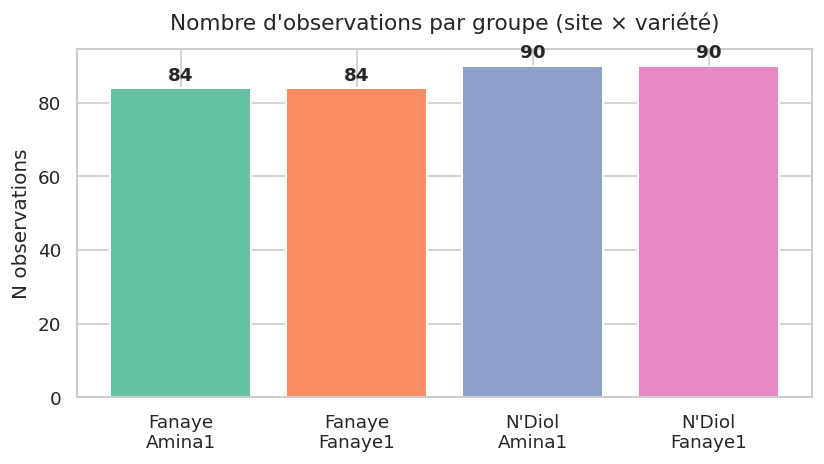

In [8]:
# ── 2.3 Distribution des observations par groupe ──────────────────────────────
print('=== Répartition des observations ===')
pivot = df.groupby(['site', 'variete']).size().reset_index(name='n_obs')
print(pivot.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
colors = sns.color_palette('Set2', len(pivot))
bars = ax.bar(pivot['site'] + '\n' + pivot['variete'], pivot['n_obs'],
              color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, pivot['n_obs']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
            ha='center', va='bottom', fontweight='bold')
ax.set_title("Nombre d'observations par groupe (site × variété)", fontsize=13, pad=12)
ax.set_ylabel('N observations')
plt.tight_layout()
plt.savefig(OUT_DIR + '2_3_repartition_obs.png', bbox_inches='tight', dpi=150)
plt.show()


=== Répartition TYPE_blé ===
TYPE_blé
ble_dur    348
Name: count, dtype: int64


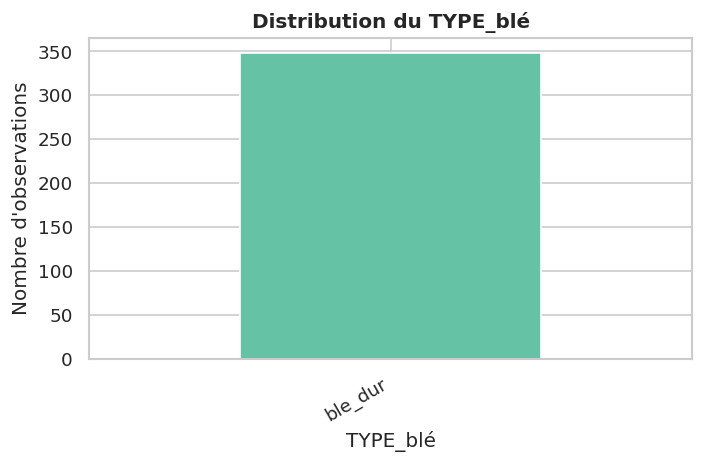

In [9]:
# ── 2.4 Distribution de la variable TYPE_blé ─────────────────────────────────
print('=== Répartition TYPE_blé ===')
print(df['TYPE_blé'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
df['TYPE_blé'].value_counts().plot(kind='bar', ax=ax, color=sns.color_palette('Set2'),
                                    edgecolor='white')
ax.set_title('Distribution du TYPE_blé', fontsize=12, fontweight='bold')
ax.set_ylabel('Nombre d\'observations')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR + '2_4_type_ble.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 🌱 Section 3 — Analyses Sol

In [10]:
# ── Palette et styles communs ─────────────────────────────────────────────────
palette = {}
for s in df['site'].unique():
    k = s.lower().replace("'", "")
    if 'fanaye' in k:
        palette[s] = '#2196F3'
    else:
        palette[s] = '#FF9800'

# Styles pour groupes site × variété
group_styles = {}
colors_g = ['#1565C0', '#42A5F5', '#E65100', '#FFA726']
lines_g  = ['-', '--', '-', '--']
for i, (s, v) in enumerate(df.groupby(['site', 'variete']).groups.keys()):
    group_styles[(s, v)] = (colors_g[i % 4], lines_g[i % 2], f'{s}–{v}')

print('Palette sites :', palette)
print('Styles groupes :', {k: v[2] for k, v in group_styles.items()})


Palette sites : {'Fanaye': '#2196F3', "N'Diol": '#FF9800'}
Styles groupes : {('Fanaye', 'Amina1'): 'Fanaye–Amina1', ('Fanaye', 'Fanaye1'): 'Fanaye–Fanaye1', ("N'Diol", 'Amina1'): "N'Diol–Amina1", ("N'Diol", 'Fanaye1'): "N'Diol–Fanaye1"}


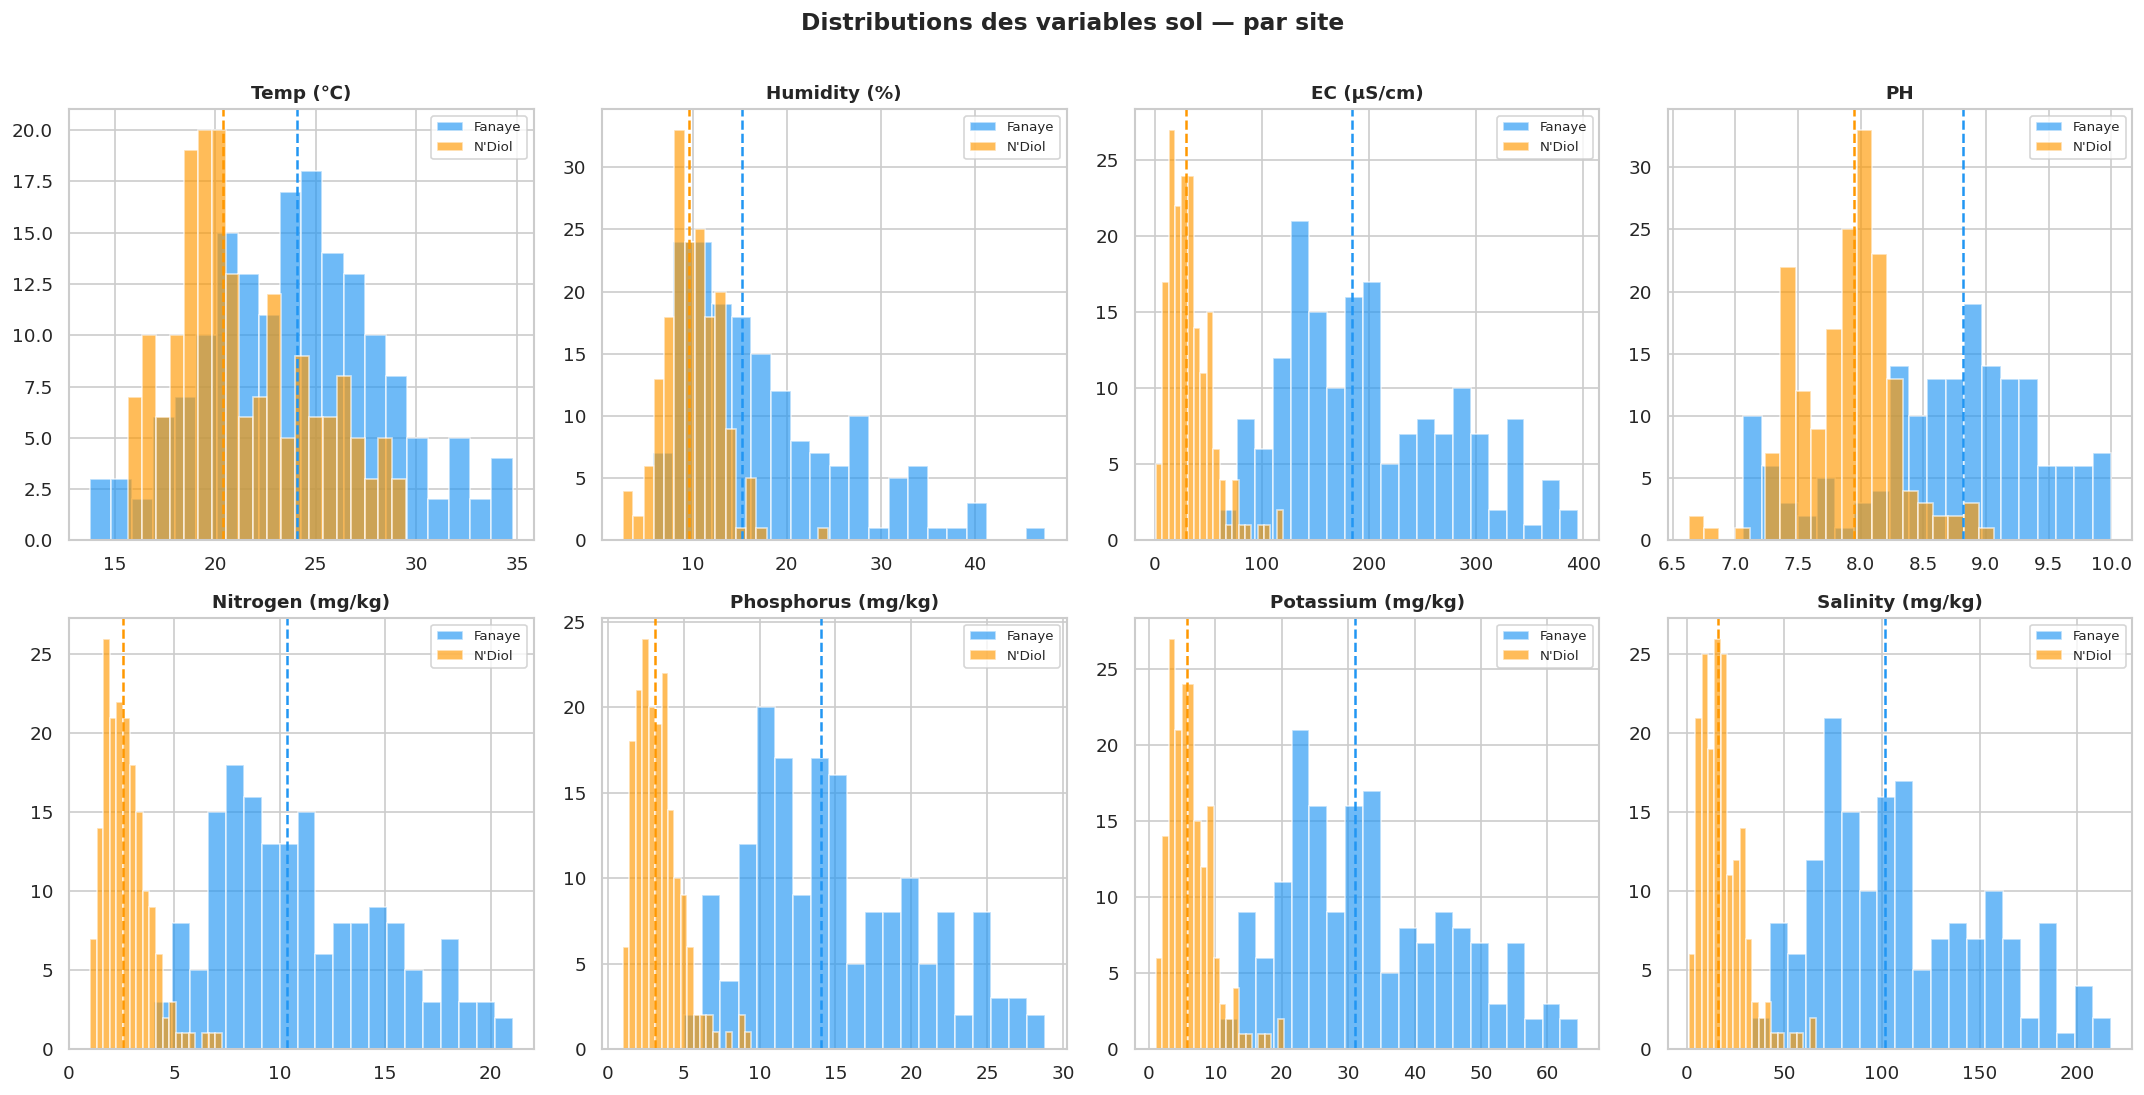

In [11]:
# ── 3.1 Distributions univariées sol ─────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(COLS_SOL):
    ax = axes[i]
    for site, grp in df.groupby('site'):
        ax.hist(grp[col].dropna(), bins=20, alpha=0.65,
                color=palette[site], label=site, edgecolor='white')
        ax.axvline(grp[col].median(), color=palette[site], linestyle='--', linewidth=1.5)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distributions des variables sol — par site', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR + '3_1_distributions_sol.png', bbox_inches='tight', dpi=150)
plt.show()


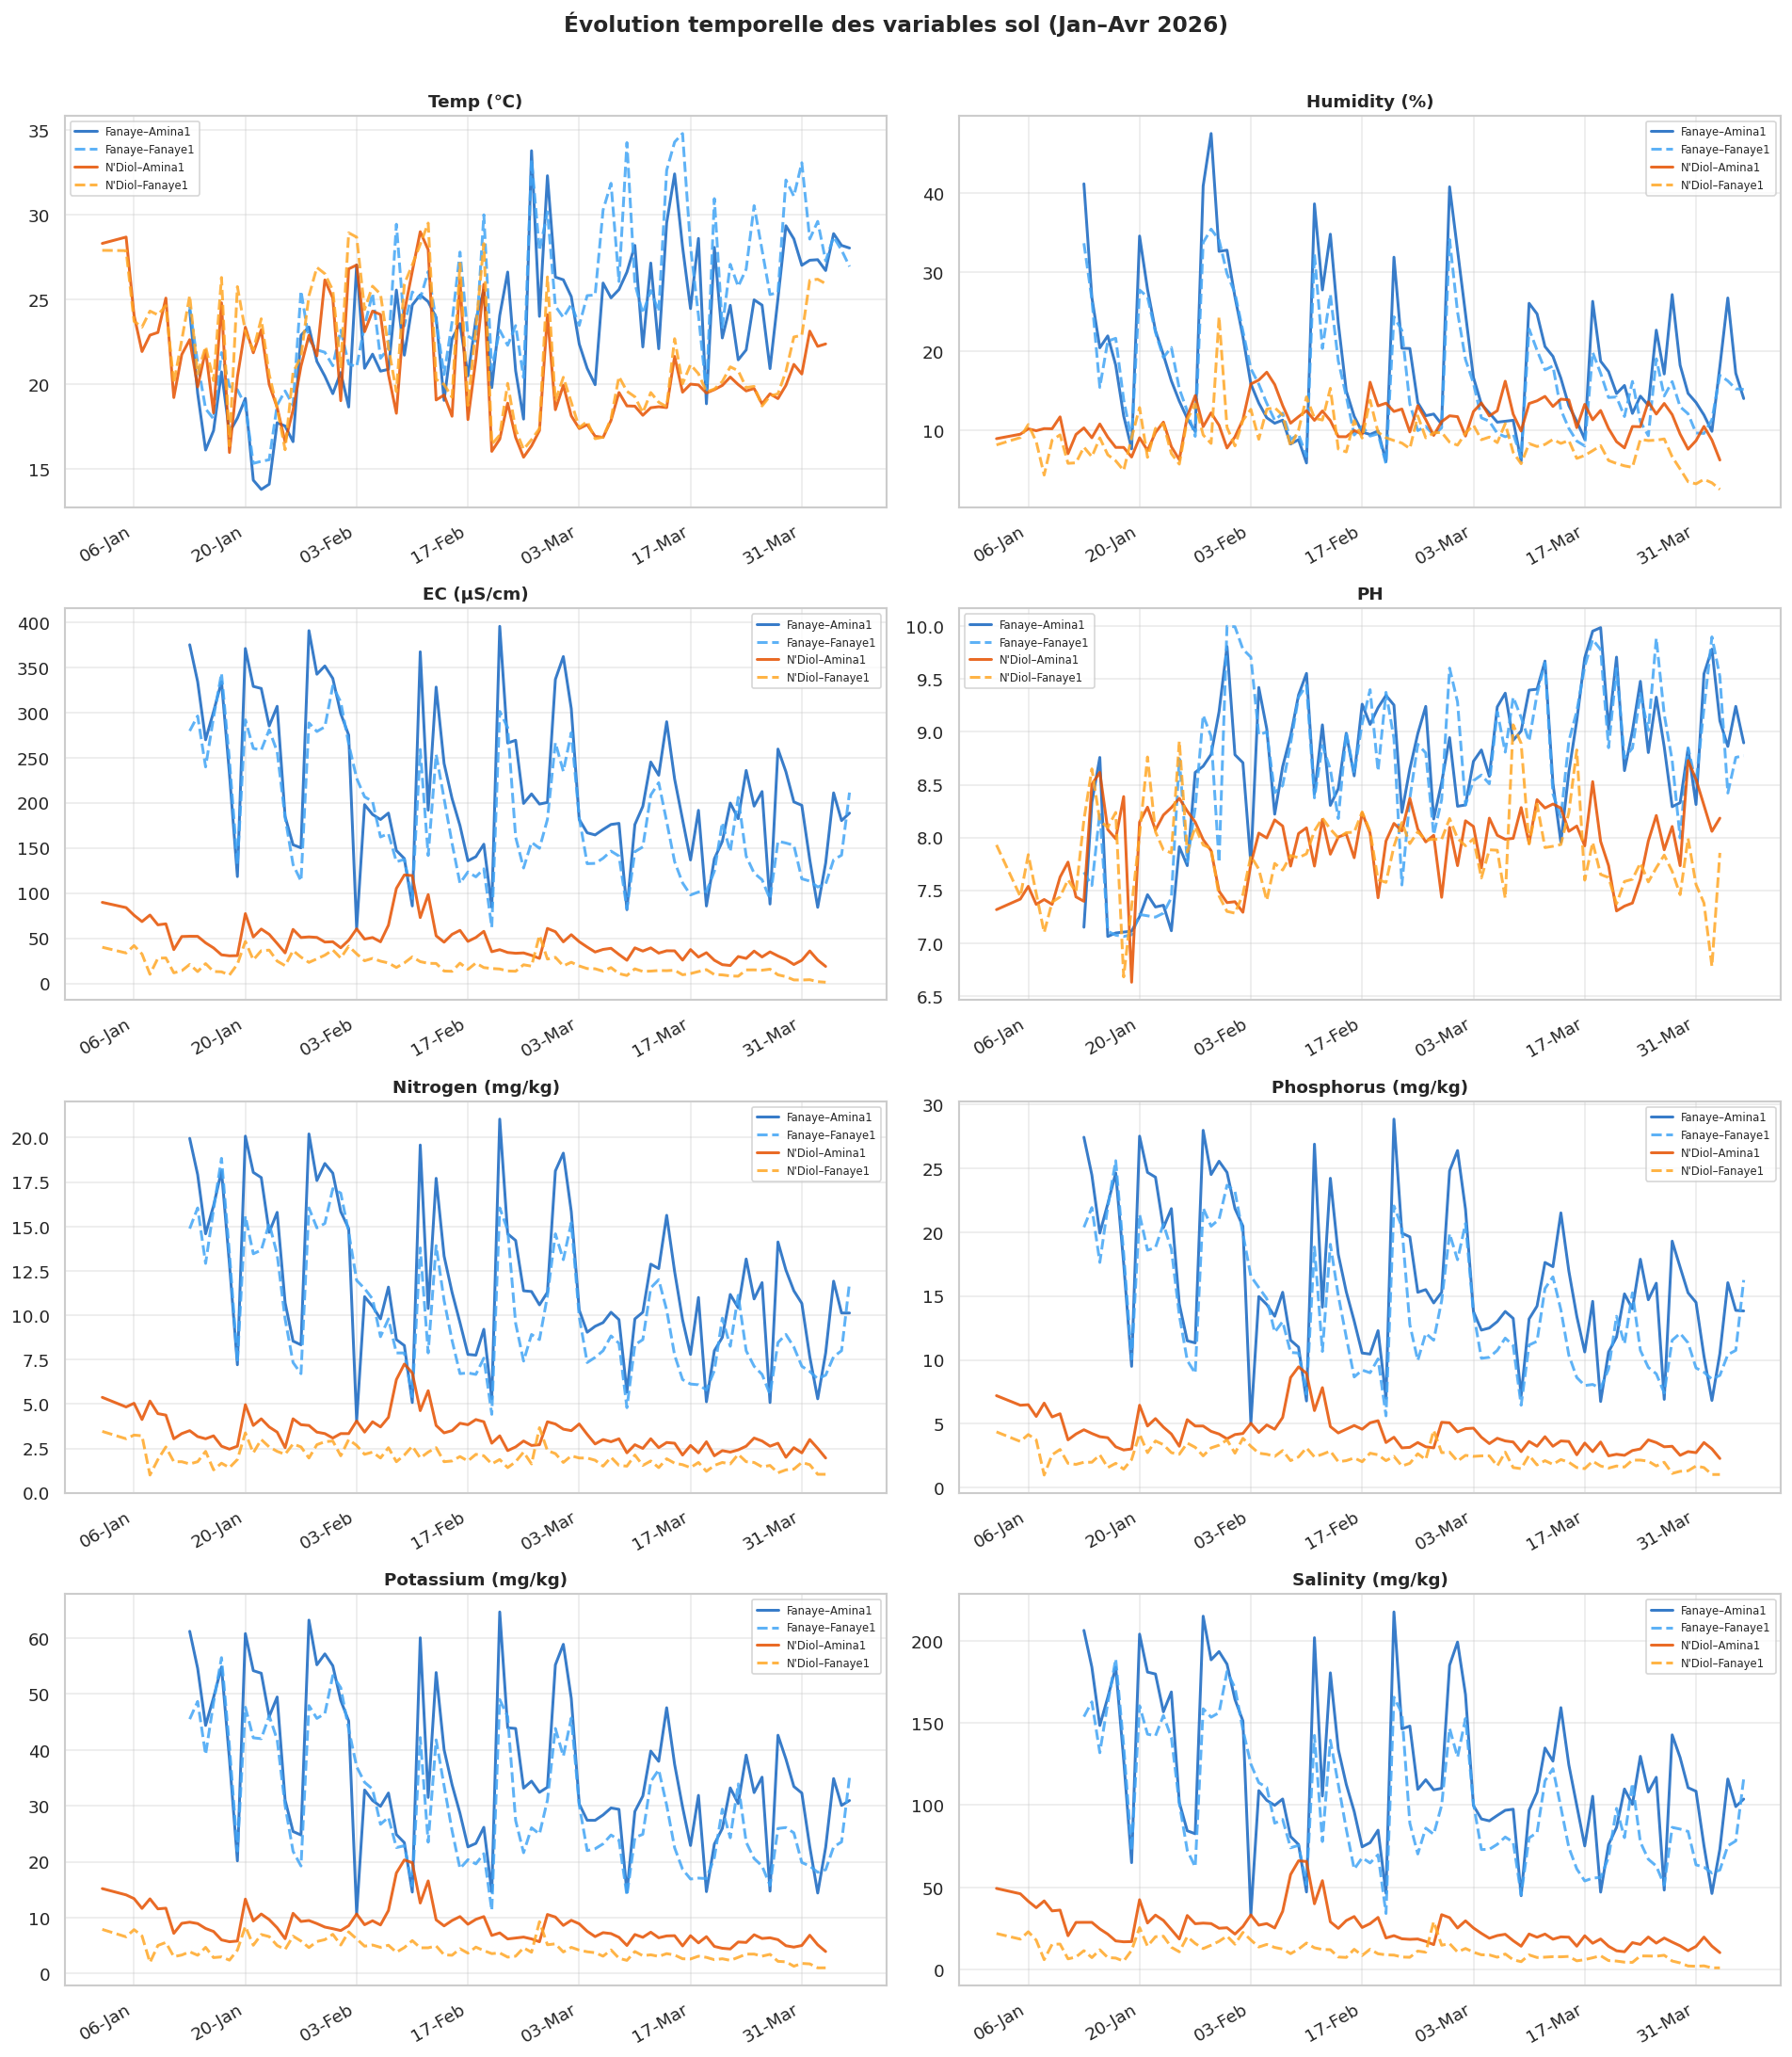

In [12]:
# ── 3.2 Évolution temporelle sol ──────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(COLS_SOL):
    ax = axes[i]
    for (site, var), grp in df.groupby(['site', 'variete']):
        if (site, var) in group_styles:
            color, ls, label = group_styles[(site, var)]
            ax.plot(grp['date'], grp[col], color=color, linestyle=ls,
                    linewidth=1.8, label=label, alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.4)

plt.suptitle('Évolution temporelle des variables sol (Jan–Avr 2026)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR + '3_2_evolution_sol.png', bbox_inches='tight', dpi=150)
plt.show()


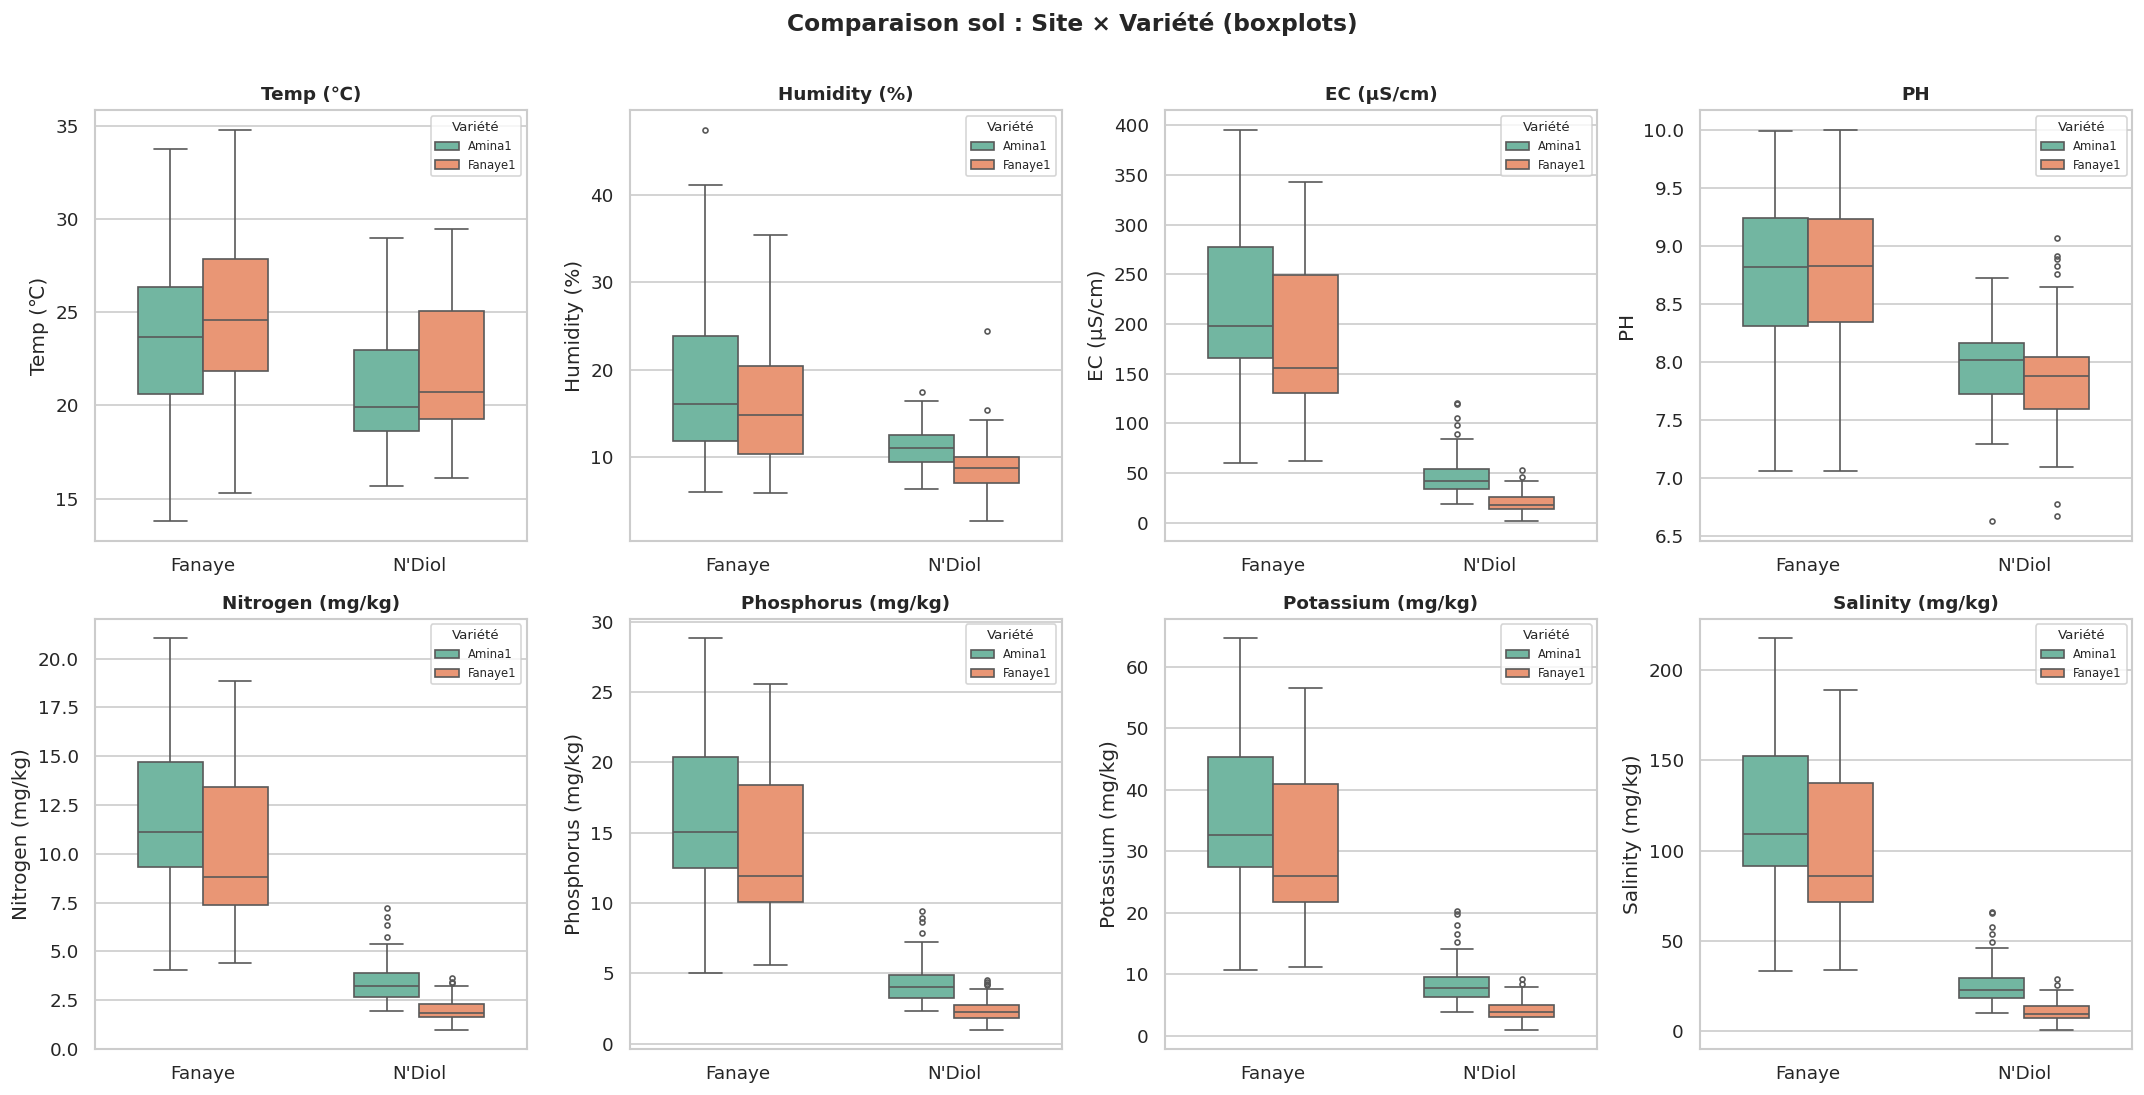

In [13]:
# ── 3.3 Boxplots comparatifs sol ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(COLS_SOL):
    ax = axes[i]
    sns.boxplot(data=df, x='site', y=col, hue='variete', ax=ax,
                palette='Set2', width=0.6, fliersize=3)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=7, title='Variété', title_fontsize=8)

plt.suptitle('Comparaison sol : Site × Variété (boxplots)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR + '3_3_boxplots_sol.png', bbox_inches='tight', dpi=150)
plt.show()


In [14]:
# ── 3.4 Test de Mann-Whitney : Fanaye vs N'Diol ───────────────────────────────
sites = df['site'].unique().tolist()
s1, s2 = sites[0], sites[1]
print(f'=== Tests Mann-Whitney — {s1} vs {s2} (variables sol) ===')
print(f'{"Variable":<25} {"Moy. " + s1[:7]:>13} {"Moy. " + s2[:7]:>13} {"p-value":>10} {"Sig.":>6}')
print('-' * 72)

for col in COLS_SOL:
    a = df[df['site'] == s1][col].dropna()
    b = df[df['site'] == s2][col].dropna()
    stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{col:<25} {a.mean():>13.3f} {b.mean():>13.3f} {p:>10.4f} {sig:>6}')

print('\nLégende : *** p<0.001  ** p<0.01  * p<0.05  ns = non significatif')


=== Tests Mann-Whitney — Fanaye vs N'Diol (variables sol) ===
Variable                    Moy. Fanaye   Moy. N'Diol    p-value   Sig.
------------------------------------------------------------------------
Temp (℃)                         24.078        21.343     0.0000    ***
Humidity (%)                     17.570         9.953     0.0000    ***
EC (μS/cm)                      200.315        33.300     0.0000    ***
PH                                8.703         7.893     0.0000    ***
Nitrogen (mg/kg)                 11.057         2.711     0.0000    ***
Phosphorus (mg/kg)               15.034         3.352     0.0000    ***
Potassium (mg/kg)                33.092         6.377     0.0000    ***
Salinity (mg/kg)                110.199        18.352     0.0000    ***

Légende : *** p<0.001  ** p<0.01  * p<0.05  ns = non significatif


---
## 🛰️ Section 4 — Analyses Indices Spectraux

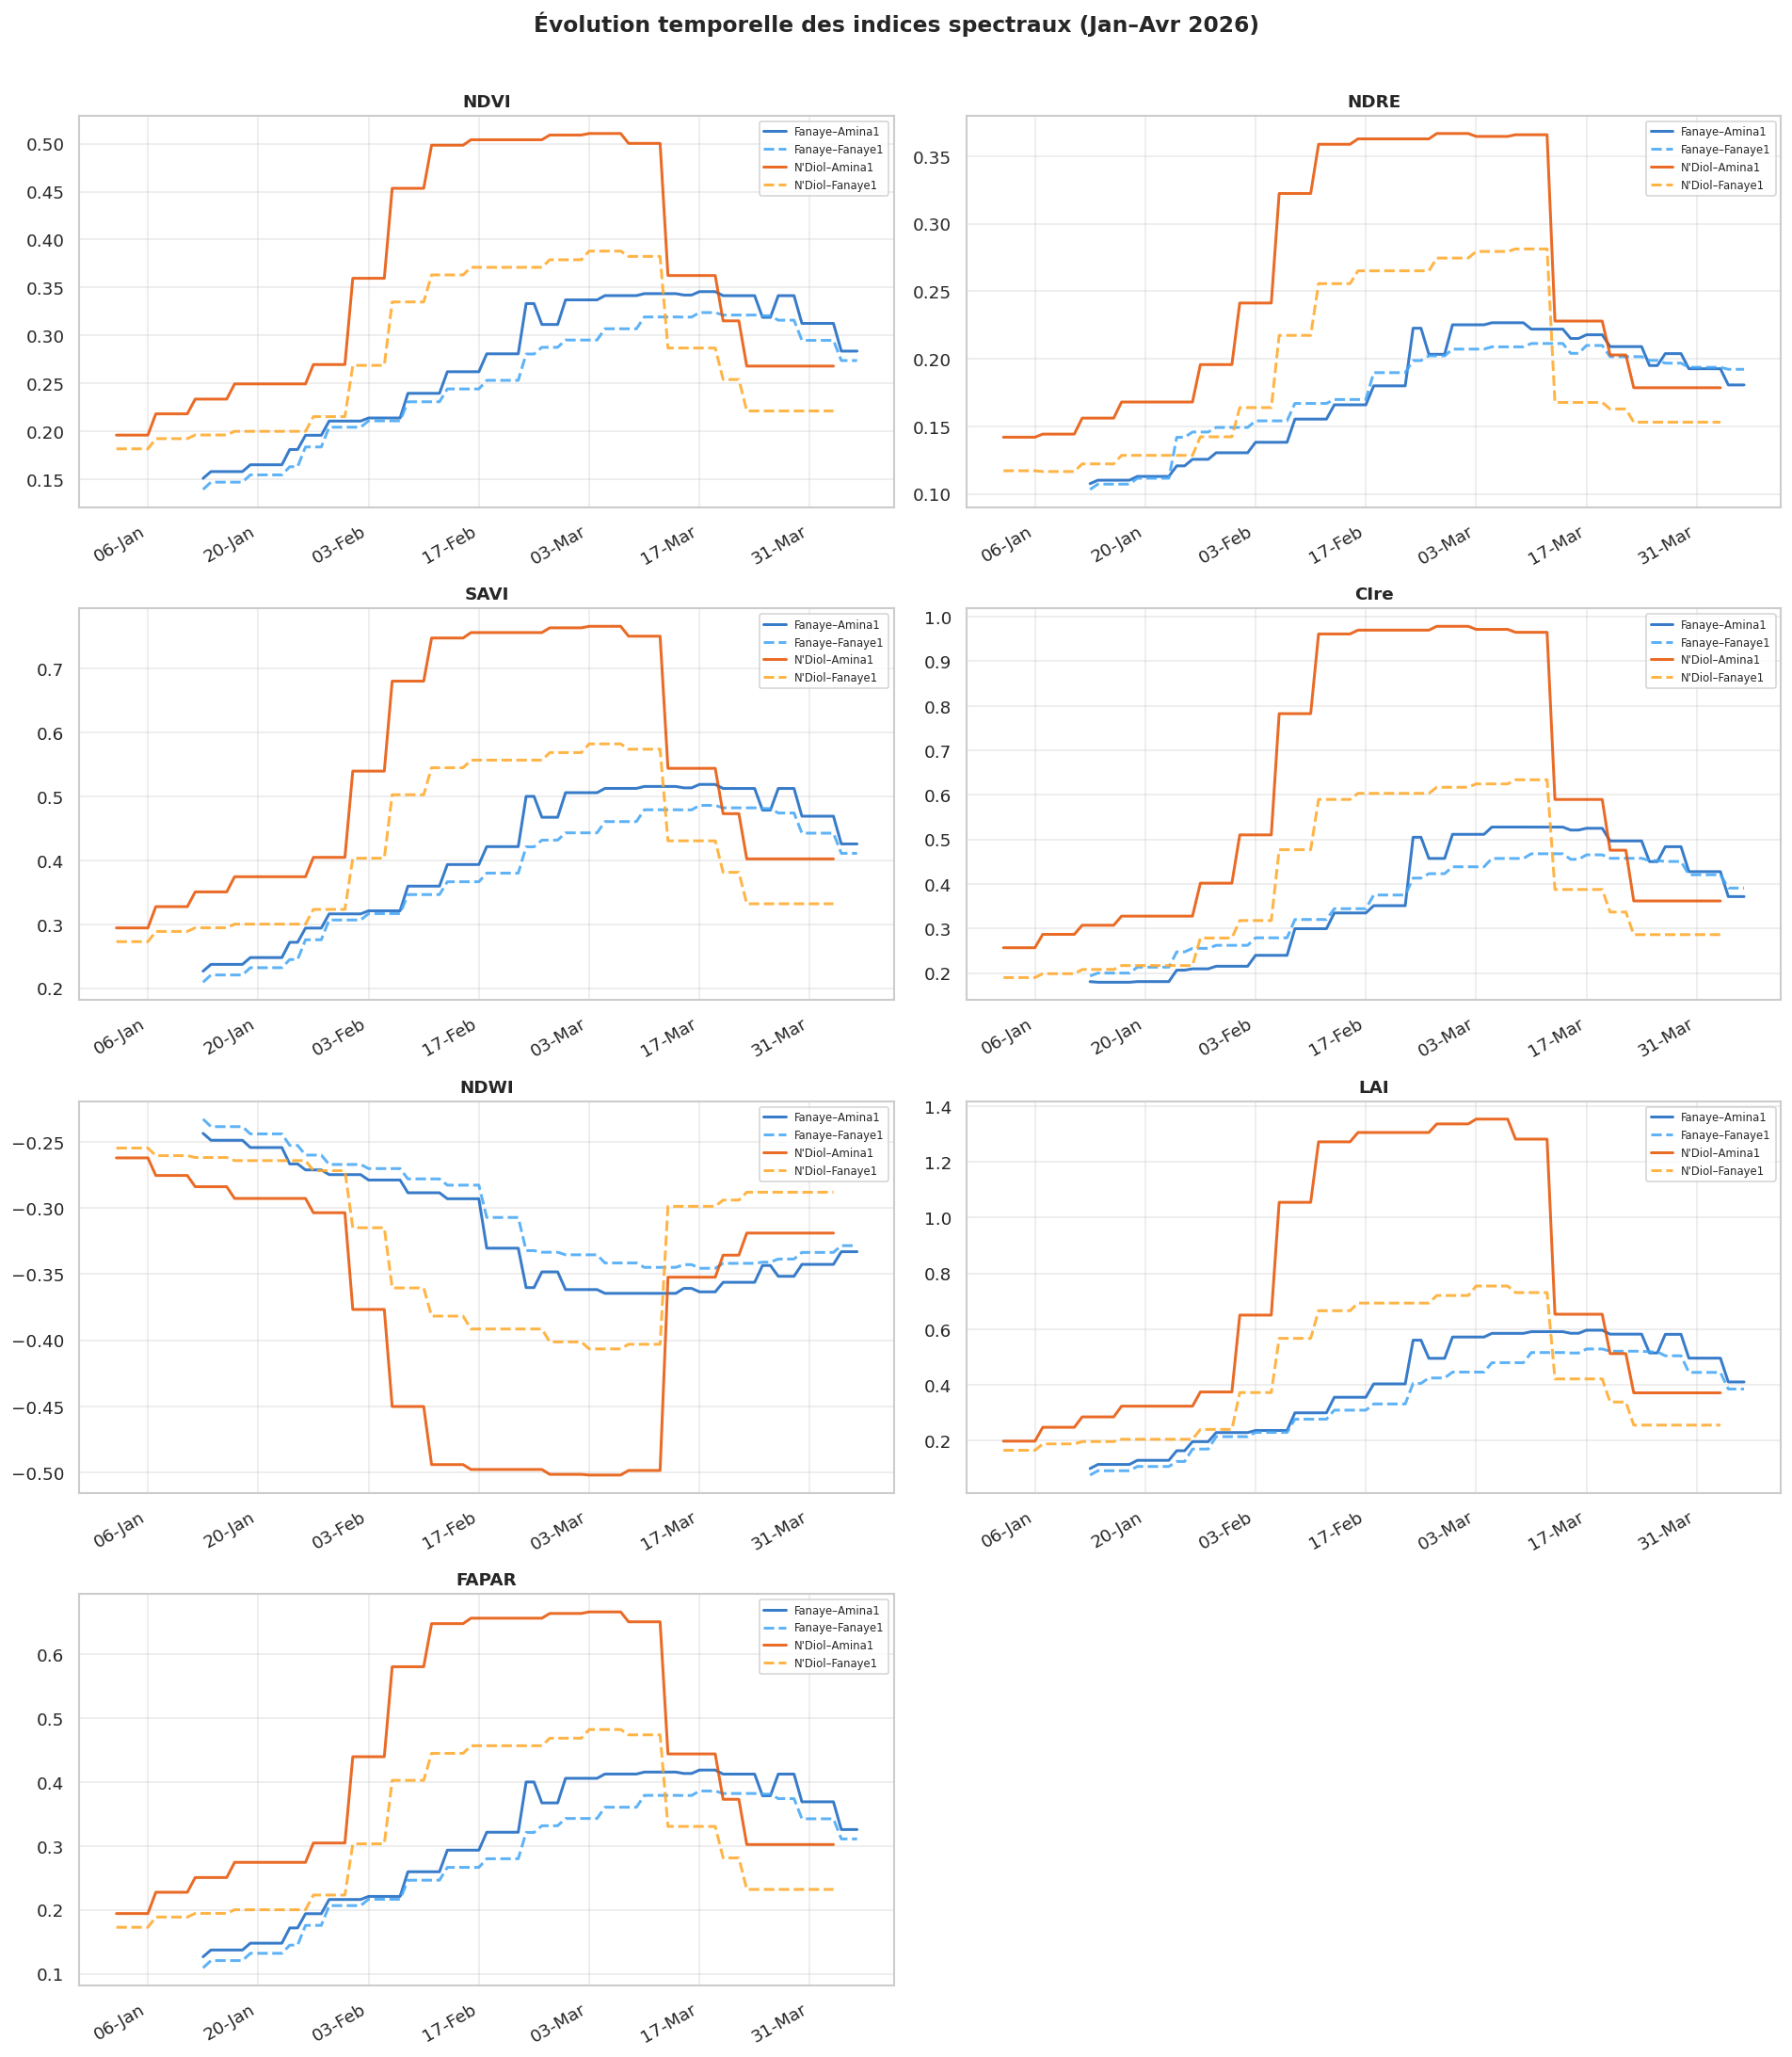

In [15]:
# ── 4.1 Évolution temporelle des indices spectraux ────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(COLS_SPEC):
    ax = axes[i]
    for (site, var), grp in df.groupby(['site', 'variete']):
        if (site, var) in group_styles:
            color, ls, label = group_styles[(site, var)]
            ax.plot(grp['date'], grp[col], color=color, linestyle=ls,
                    linewidth=1.8, label=label, alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)

# Masquer le subplot en trop
for j in range(len(COLS_SPEC), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Évolution temporelle des indices spectraux (Jan–Avr 2026)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR + '4_1_evolution_spectral.png', bbox_inches='tight', dpi=150)
plt.show()


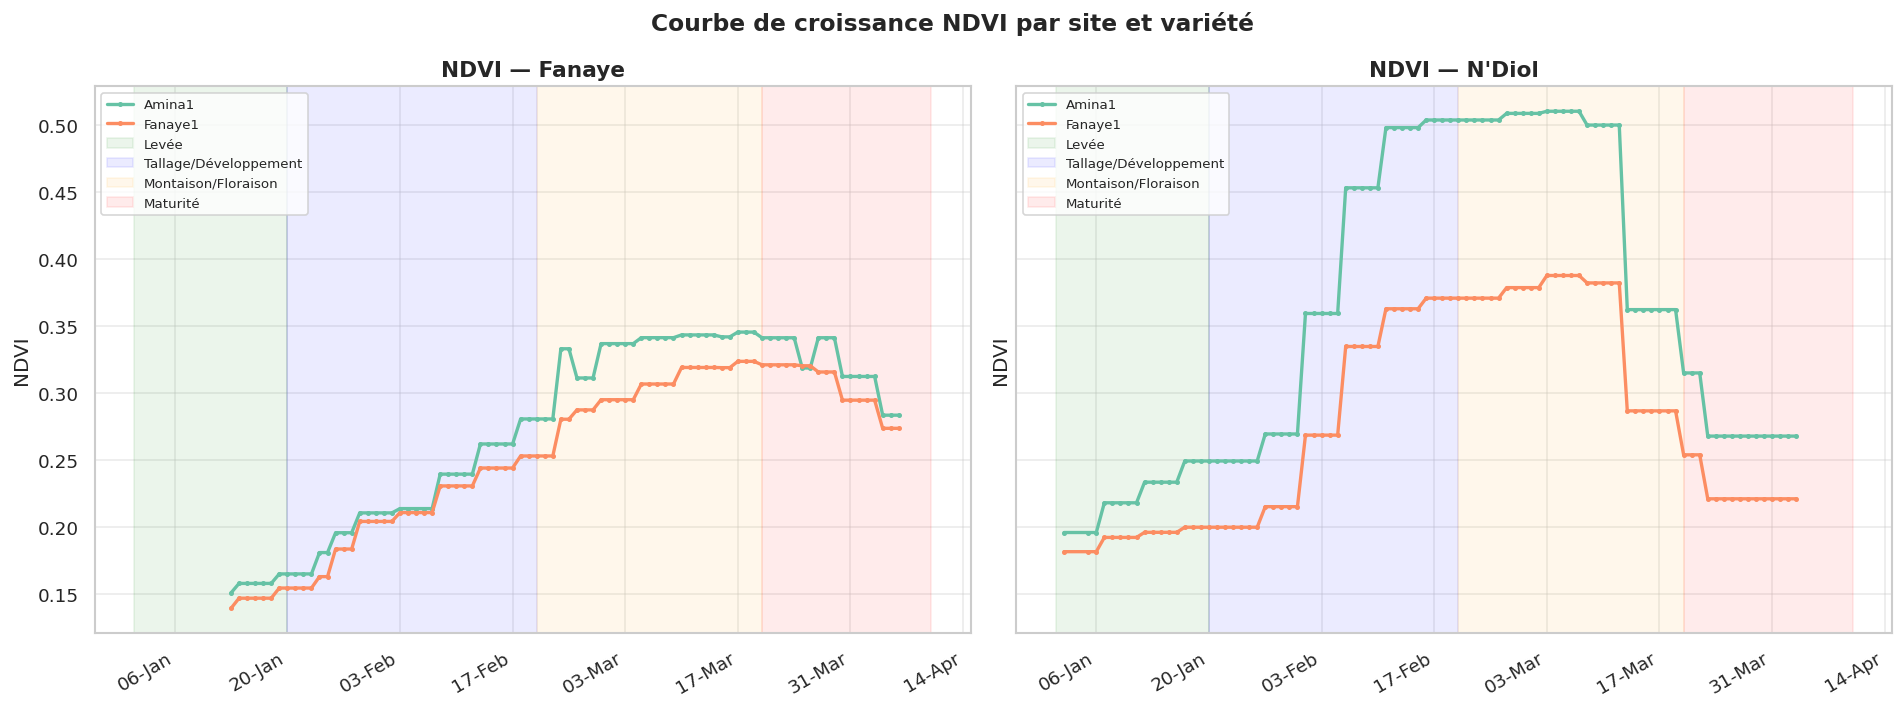

In [16]:
# ── 4.2 NDVI — Courbe de croissance avec stades phénologiques ────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sites_list = df['site'].unique().tolist()

for ax, site in zip(axes, sites_list):
    sub = df[df['site'] == site]
    for var, grp in sub.groupby('variete'):
        ax.plot(grp['date'], grp['NDVI'], linewidth=2, label=var, marker='o', markersize=2)
    ax.axvspan(pd.Timestamp('2026-01-01'), pd.Timestamp('2026-01-20'),
               alpha=0.08, color='green', label='Levée')
    ax.axvspan(pd.Timestamp('2026-01-20'), pd.Timestamp('2026-02-20'),
               alpha=0.08, color='blue', label='Tallage/Développement')
    ax.axvspan(pd.Timestamp('2026-02-20'), pd.Timestamp('2026-03-20'),
               alpha=0.08, color='orange', label='Montaison/Floraison')
    ax.axvspan(pd.Timestamp('2026-03-20'), pd.Timestamp('2026-04-10'),
               alpha=0.08, color='red', label='Maturité')
    ax.set_title(f'NDVI — {site}', fontsize=13, fontweight='bold')
    ax.set_ylabel('NDVI')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.4)

plt.suptitle('Courbe de croissance NDVI par site et variété', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '4_2_ndvi_croissance.png', bbox_inches='tight', dpi=150)
plt.show()


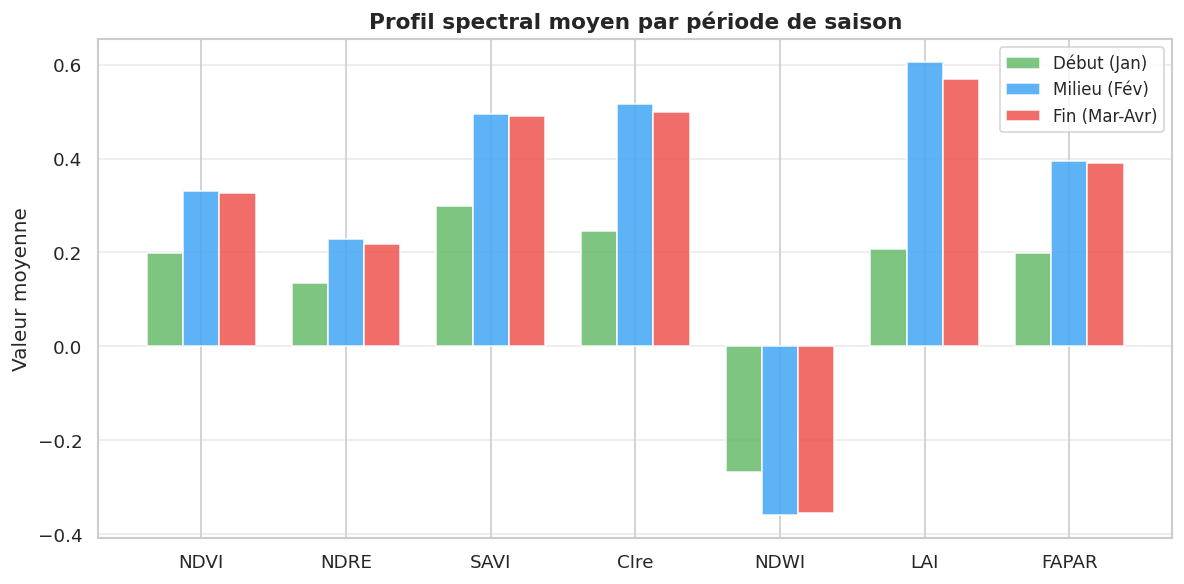

In [17]:
# ── 4.3 Profil spectral moyen par période ─────────────────────────────────────
def get_periode(date):
    if date < pd.Timestamp('2026-02-01'): return 'Début (Jan)'
    elif date < pd.Timestamp('2026-03-01'): return 'Milieu (Fév)'
    else: return 'Fin (Mar-Avr)'

df['periode'] = df['date'].apply(get_periode)

profil = df.groupby('periode')[COLS_SPEC].mean()
ordre_periodes = ['Début (Jan)', 'Milieu (Fév)', 'Fin (Mar-Avr)']
profil = profil.reindex(ordre_periodes)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(COLS_SPEC))
width = 0.25
colors_p = ['#66BB6A', '#42A5F5', '#EF5350']

for i, (periode_name, row) in enumerate(profil.iterrows()):
    ax.bar(x + i*width, row.values, width, label=periode_name,
           color=colors_p[i], edgecolor='white', alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(COLS_SPEC, fontsize=11)
ax.set_title('Profil spectral moyen par période de saison', fontsize=13, fontweight='bold')
ax.set_ylabel('Valeur moyenne')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR + '4_3_profil_spectral.png', bbox_inches='tight', dpi=150)
plt.show()


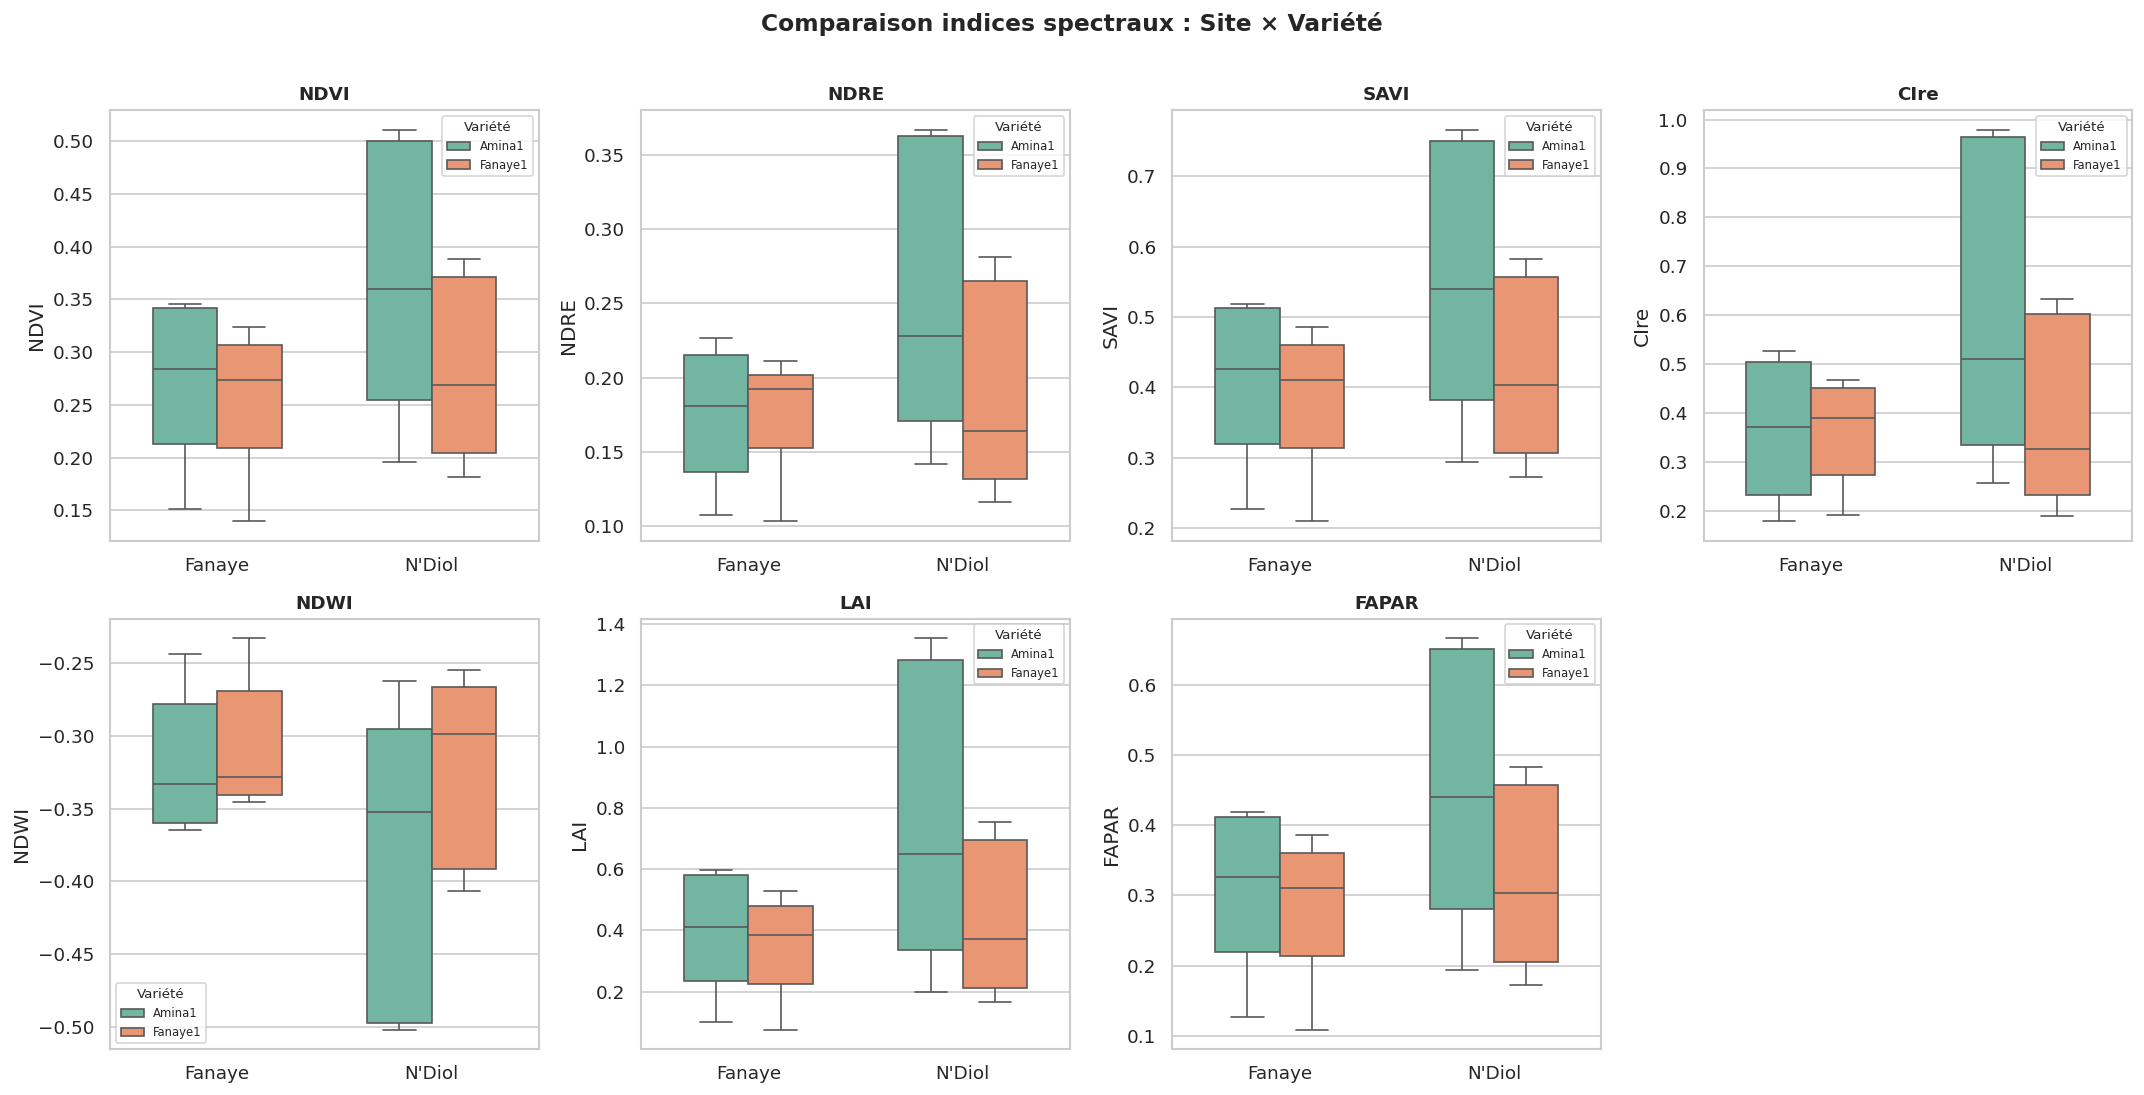

In [18]:
# ── 4.4 Boxplots indices spectraux par site ───────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(COLS_SPEC):
    ax = axes[i]
    sns.boxplot(data=df, x='site', y=col, hue='variete', ax=ax,
                palette='Set2', width=0.6, fliersize=3)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=7, title='Variété', title_fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Comparaison indices spectraux : Site × Variété', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR + '4_4_boxplots_spectral.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 📡 Section 5 — Analyses SAR (Radar) & Variables Climatiques

---

## 🎛️ Section 6 (new) — Harmonisation des variables

In [19]:
# ── Imports pour la standardisation ────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# ── Définition des groupes de variables (répétées pour autonomie du bloc) ───
COLS_SOL    = ['Temp (℃)', 'Humidity (%)', 'EC (μS/cm)', 'PH',
               'Nitrogen (mg/kg)', 'Phosphorus (mg/kg)', 'Potassium (mg/kg)', 'Salinity (mg/kg)']
COLS_SPEC   = ['NDVI', 'NDRE', 'SAVI', 'CIre', 'NDWI', 'LAI', 'FAPAR']
COLS_SAR    = ['VV', 'VH', 'RVI', 'VH_VV', 'SSM']
COLS_BIO    = ['BIOMASSE_CUM']
COLS_CLIMAT = ['temp_min_C', 'temp_moy_C', 'temp_max_C',
               'hum_rel_min_pct', 'hum_rel_moy_pct', 'hum_rel_max_pct',
               'pluie_mm', 'vent_ms', 'rad_sol_Jcm2', 'rad_sol_MJm2']

# ── Définition des colonnes à harmoniser ───────────────────────────────────
# Exclure 'pluie_mm' et 'rad_sol_Jcm2' car elles pourraient ne pas bénéficier de la standardisation
# dans le même sens que les autres ou sont déjà en unité comparable. On utilisera 'rad_sol_MJm2'

# Combine all numerical columns that need standardization
COLS_TO_STANDARDIZE = COLS_SOL + COLS_SPEC + COLS_SAR + COLS_BIO + [
    col for col in COLS_CLIMAT if col not in ['pluie_mm', 'rad_sol_Jcm2']
]

# Initialize the StandardScaler
scaler = StandardScaler()

# Create a copy of the DataFrame for standardized values
df_scaled = df.copy()

# Apply StandardScaler to the selected columns
df_scaled[COLS_TO_STANDARDIZE] = scaler.fit_transform(df_scaled[COLS_TO_STANDARDIZE])

print("✅ Variables numériques harmonisées (standardisation) dans 'df_scaled'")
print("Aperçu des données standardisées:")
display(df_scaled[COLS_TO_STANDARDIZE].head())

✅ Variables numériques harmonisées (standardisation) dans 'df_scaled'
Aperçu des données standardisées:


,Temp (℃),Humidity (%),EC (μS/cm),PH,Nitrogen (mg/kg),Phosphorus (mg/kg),Potassium (mg/kg),Salinity (mg/kg),NDVI,NDRE,...,SSM,BIOMASSE_CUM,temp_min_C,temp_moy_C,temp_max_C,hum_rel_min_pct,hum_rel_moy_pct,hum_rel_max_pct,vent_ms,rad_sol_MJm2
0,0.404323,3.768136,2.591417,-1.582911,2.615341,2.607935,2.600443,2.591607,-1.538418,-1.337321,...,2.147111,-0.727071,-0.231930,-0.243319,-0.132409,-0.316466,-0.160662,-0.281050,-1.427462,-0.329075
1,-0.772169,1.803792,2.185624,0.068470,2.211390,2.189198,2.189614,2.187678,-1.461888,-1.300051,...,2.401842,-0.726094,-0.833360,-0.243319,0.065231,-0.617423,-0.468237,0.159820,-1.405563,0.297596
2,-1.577195,0.934677,1.546531,0.661588,1.551842,1.546373,1.556577,1.547561,-1.461888,-1.300051,...,2.656573,-0.725118,0.098856,-0.347002,-0.612391,-0.266306,-1.049211,-2.078443,-0.485805,0.381776
3,-1.301852,1.140249,1.855529,-1.705024,1.865134,1.870729,1.866637,1.855208,-1.461888,-1.300051,...,2.411290,-0.724141,-1.224288,-0.727175,-0.471220,-0.316466,-0.570762,0.261559,-1.077078,0.447249
4,-0.468782,0.634310,2.185624,-1.658551,2.252604,2.212793,2.205117,2.186925,-1.461888,-1.300051,...,2.166008,-0.723164,-1.073931,-0.899981,-0.922968,-0.466944,-0.741636,-0.586267,-0.507704,0.144202


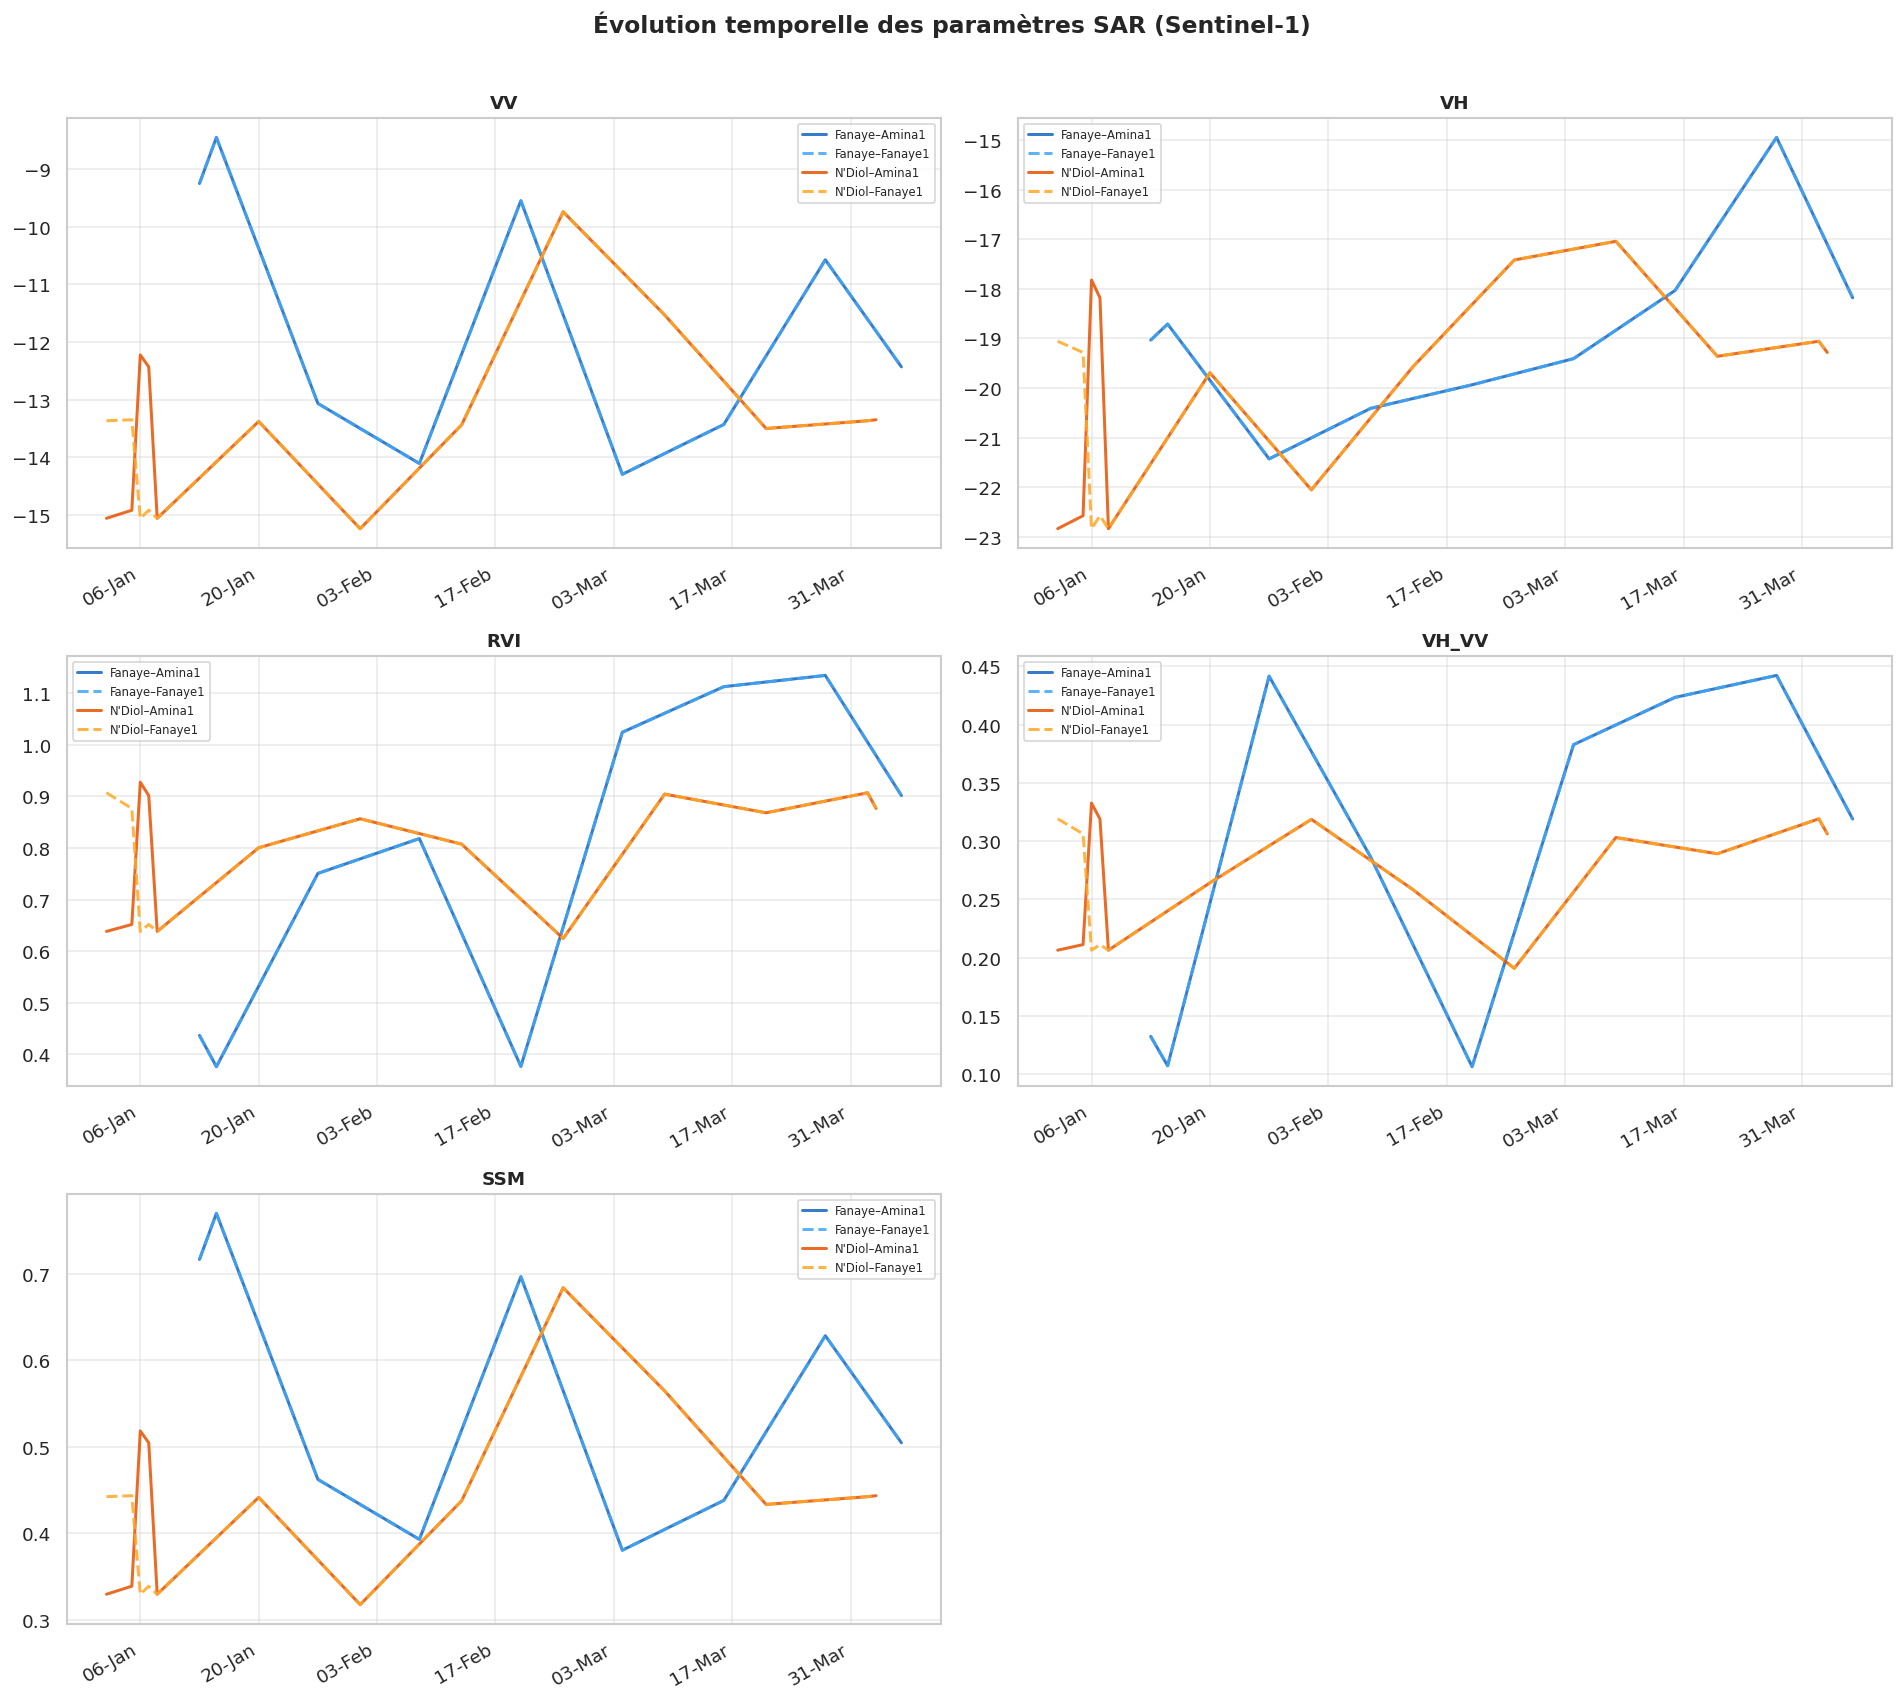

In [20]:
# ── 5.1 Évolution temporelle SAR ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(COLS_SAR):
    ax = axes[i]
    for (site, var), grp in df.groupby(['site', 'variete']):
        if (site, var) in group_styles:
            color, ls, label = group_styles[(site, var)]
            ax.plot(grp['date'], grp[col], color=color, linestyle=ls,
                    linewidth=1.8, label=label, alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)

axes[-1].set_visible(False)
plt.suptitle('Évolution temporelle des paramètres SAR (Sentinel-1)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR + '5_1_evolution_SAR.png', bbox_inches='tight', dpi=150)
plt.show()


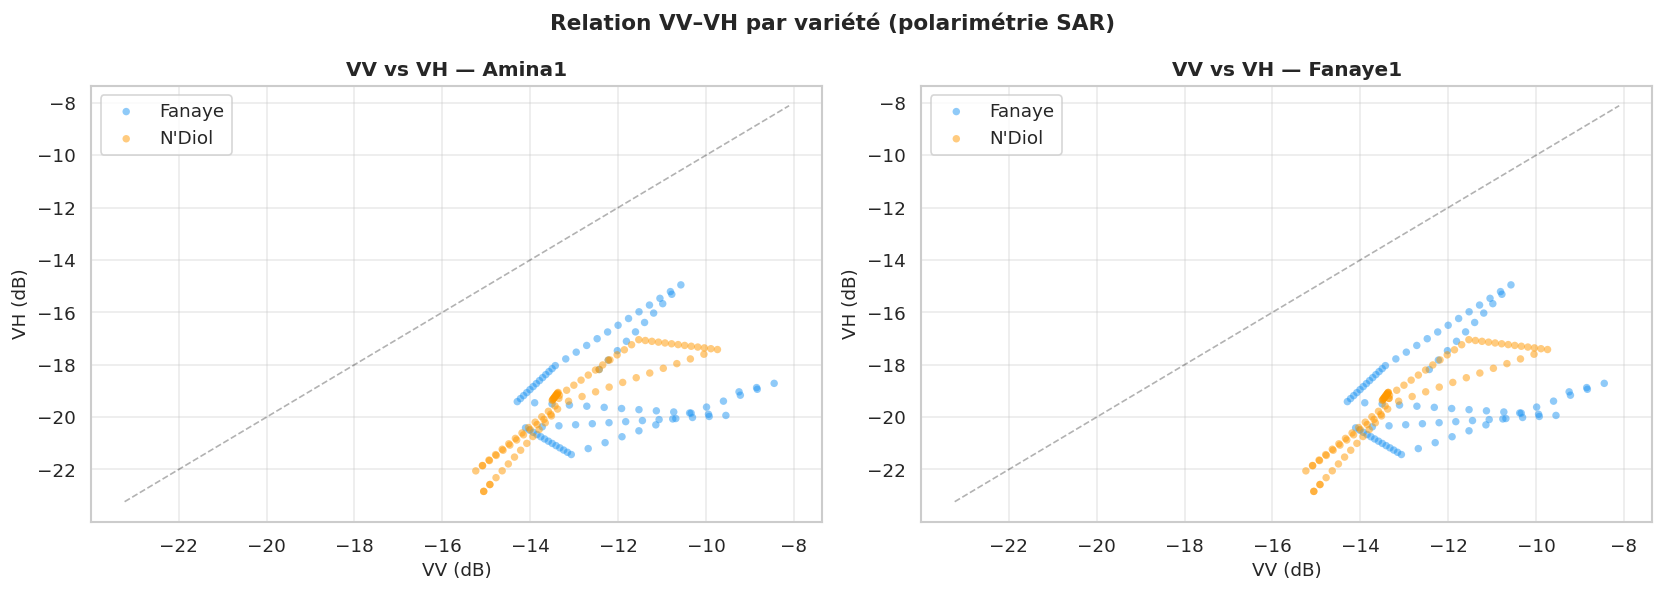

In [21]:
# ── 5.2 Scatter VV vs VH coloré par site ─────────────────────────────────────
varietes = df['variete'].unique().tolist()
fig, axes = plt.subplots(1, len(varietes), figsize=(7*len(varietes), 5))
if len(varietes) == 1:
    axes = [axes]

for ax, var in zip(axes, varietes):
    sub = df[df['variete'] == var]
    for site, grp in sub.groupby('site'):
        ax.scatter(grp['VV'], grp['VH'], c=palette[site], alpha=0.5,
                   label=site, s=20, edgecolors='none')
    ax.set_xlabel('VV (dB)', fontsize=11)
    ax.set_ylabel('VH (dB)', fontsize=11)
    ax.set_title(f'VV vs VH — {var}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.4)
    lim = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
           max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lim, lim, 'k--', alpha=0.3, linewidth=1)

plt.suptitle('Relation VV–VH par variété (polarimétrie SAR)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '5_2_scatter_VVVH.png', bbox_inches='tight', dpi=150)
plt.show()


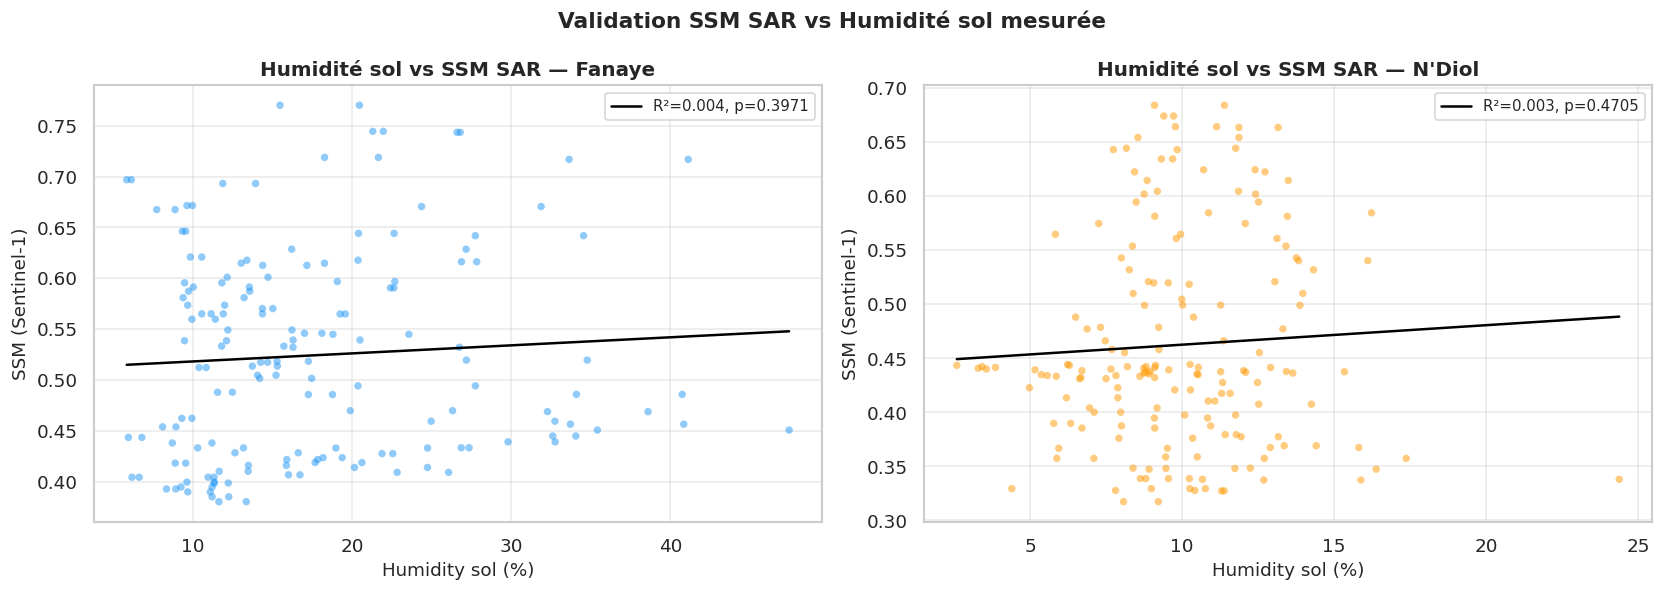

In [22]:
# ── 5.3 SSM — Comparaison avec Humidity sol ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, site in zip(axes, df['site'].unique()):
    sub = df[df['site'] == site].dropna(subset=['Humidity (%)', 'SSM'])
    ax.scatter(sub['Humidity (%)'], sub['SSM'], c=palette[site],
               alpha=0.5, s=20, edgecolors='none')
    m, b, r, p, _ = stats.linregress(sub['Humidity (%)'], sub['SSM'])
    x_line = np.linspace(sub['Humidity (%)'].min(), sub['Humidity (%)'].max(), 100)
    ax.plot(x_line, m*x_line + b, 'k-', linewidth=1.5,
            label=f'R²={r**2:.3f}, p={p:.4f}')
    ax.set_xlabel('Humidity sol (%)', fontsize=11)
    ax.set_ylabel('SSM (Sentinel-1)', fontsize=11)
    ax.set_title(f'Humidité sol vs SSM SAR — {site}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

plt.suptitle('Validation SSM SAR vs Humidité sol mesurée', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '5_3_SSM_validation.png', bbox_inches='tight', dpi=150)
plt.show()


In [23]:
# ── 5.4 Statistiques descriptives — Variables Climatiques ────────────────────
print('=== Statistiques descriptives — Variables Climatiques ===')
display(df[COLS_CLIMAT].describe().round(3))


=== Statistiques descriptives — Variables Climatiques ===


,temp_min_C,temp_moy_C,temp_max_C,hum_rel_min_pct,hum_rel_moy_pct,hum_rel_max_pct,pluie_mm,vent_ms,rad_sol_Jcm2,rad_sol_MJm2
count,348.000,348.000,348.000,348.000,348.000,348.000,348.000,348.000,348.000,348.000
mean,14.971,23.804,34.969,8.655,36.851,68.144,0.032,1.669,1768.914,17.689
std,3.330,2.898,3.547,9.983,14.652,14.765,0.247,0.529,535.341,5.353
min,7.900,18.500,26.800,0.000,11.500,33.000,0.000,0.498,498.000,4.980
25%,12.500,21.900,32.100,1.200,25.000,57.500,0.000,1.308,1369.000,13.690
50%,15.300,23.300,35.300,5.000,36.250,71.000,0.000,1.586,1630.500,16.305
75%,17.500,25.000,37.700,11.500,46.600,80.500,0.000,2.002,2203.000,22.030
max,26.700,33.800,42.700,43.000,72.000,91.000,3.000,3.600,3917.000,39.170


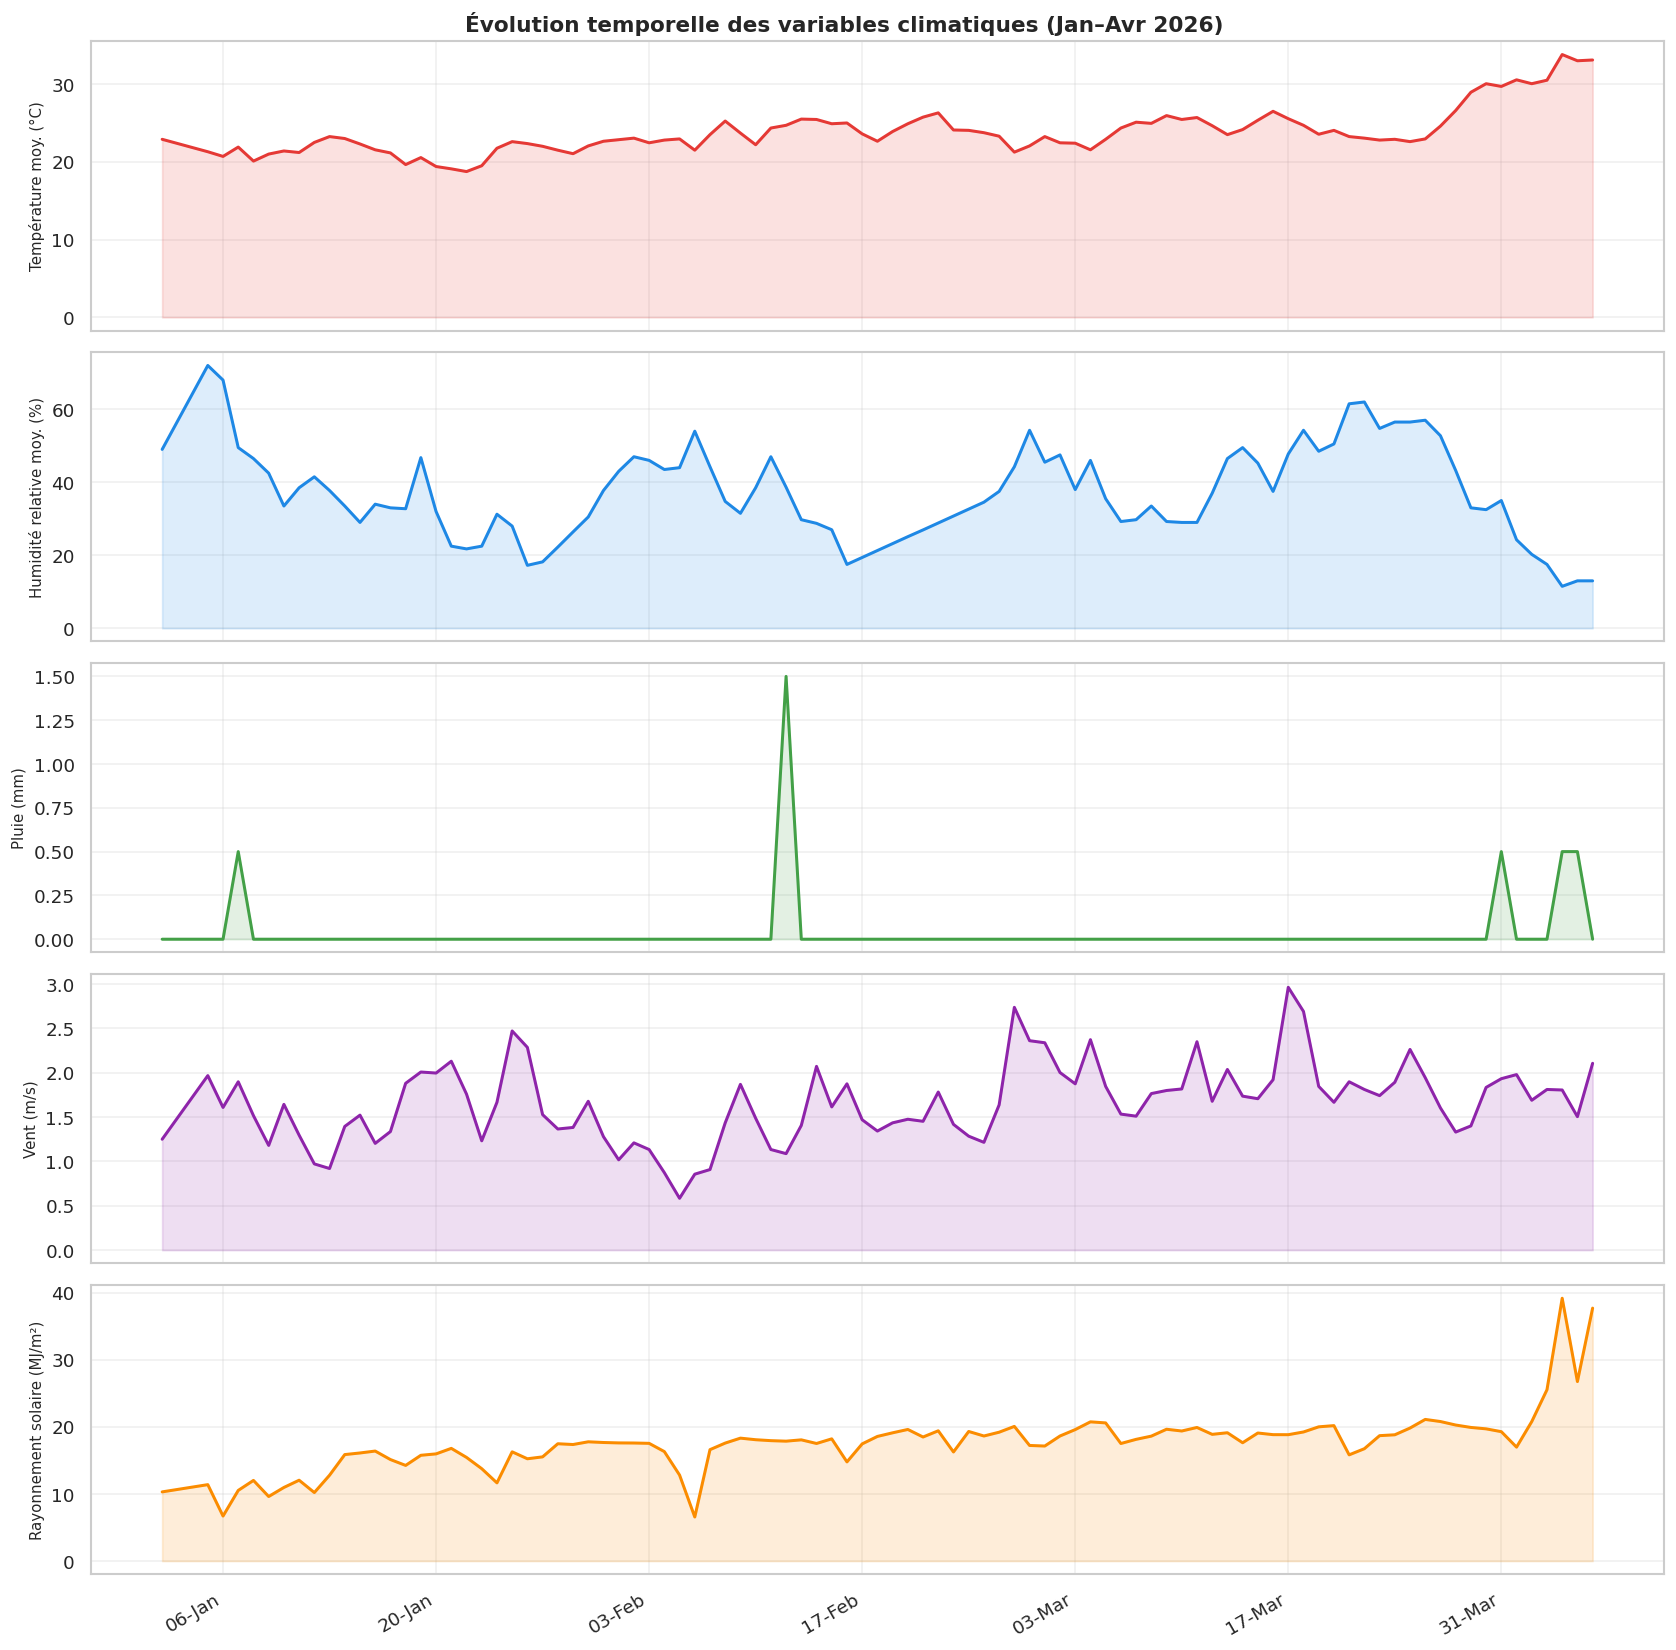

In [24]:
# ── 5.5 Évolution temporelle des variables climatiques ────────────────────────
COLS_CLIMAT_PLOT = ['temp_moy_C', 'hum_rel_moy_pct', 'pluie_mm', 'vent_ms',
                    'rad_sol_MJm2']

fig, axes = plt.subplots(len(COLS_CLIMAT_PLOT), 1, figsize=(14, 14), sharex=True)

# On prend une seule série temporelle (même valeur par date tous sites confondus)
df_clim = df.groupby('date')[COLS_CLIMAT_PLOT].mean().reset_index()

colors_cl = ['#E53935', '#1E88E5', '#43A047', '#8E24AA', '#FB8C00']
labels_cl = ['Température moy. (°C)', 'Humidité relative moy. (%)',
             'Pluie (mm)', 'Vent (m/s)', 'Rayonnement solaire (MJ/m²)']

for ax, col, color, label in zip(axes, COLS_CLIMAT_PLOT, colors_cl, labels_cl):
    ax.plot(df_clim['date'], df_clim[col], color=color, linewidth=1.8)
    ax.fill_between(df_clim['date'], df_clim[col], alpha=0.15, color=color)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Évolution temporelle des variables climatiques (Jan–Avr 2026)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '5_5_evolution_climatique.png', bbox_inches='tight', dpi=150)
plt.show()


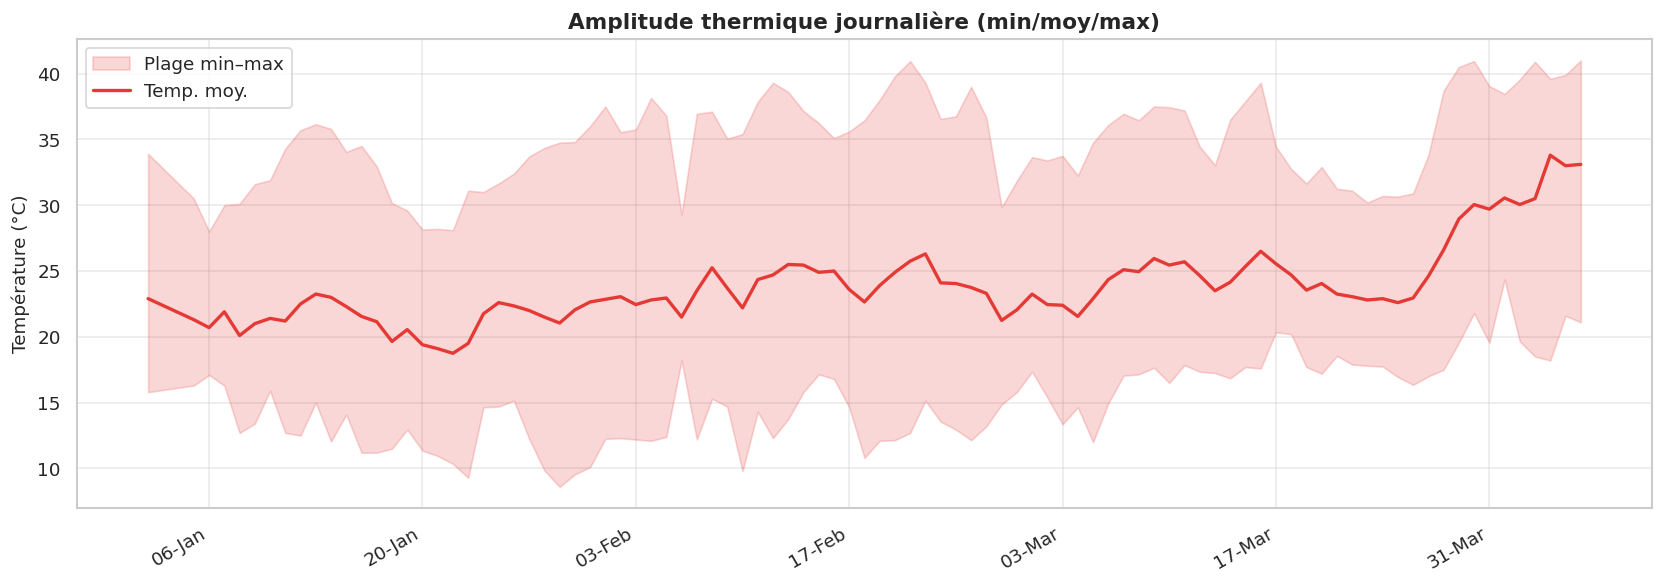

In [25]:
# ── 5.6 Températures min / moy / max ─────────────────────────────────────────
df_clim2 = df.groupby('date')[['temp_min_C', 'temp_moy_C', 'temp_max_C']].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df_clim2['date'], df_clim2['temp_min_C'], df_clim2['temp_max_C'],
                alpha=0.2, color='#E53935', label='Plage min–max')
ax.plot(df_clim2['date'], df_clim2['temp_moy_C'], color='#E53935', linewidth=2, label='Temp. moy.')
ax.set_ylabel('Température (°C)', fontsize=11)
ax.set_title('Amplitude thermique journalière (min/moy/max)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR + '5_6_amplitude_thermique.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 🌾 Section 6 — Biomasse (BIOMASSE & BIOMASSE_CUM)

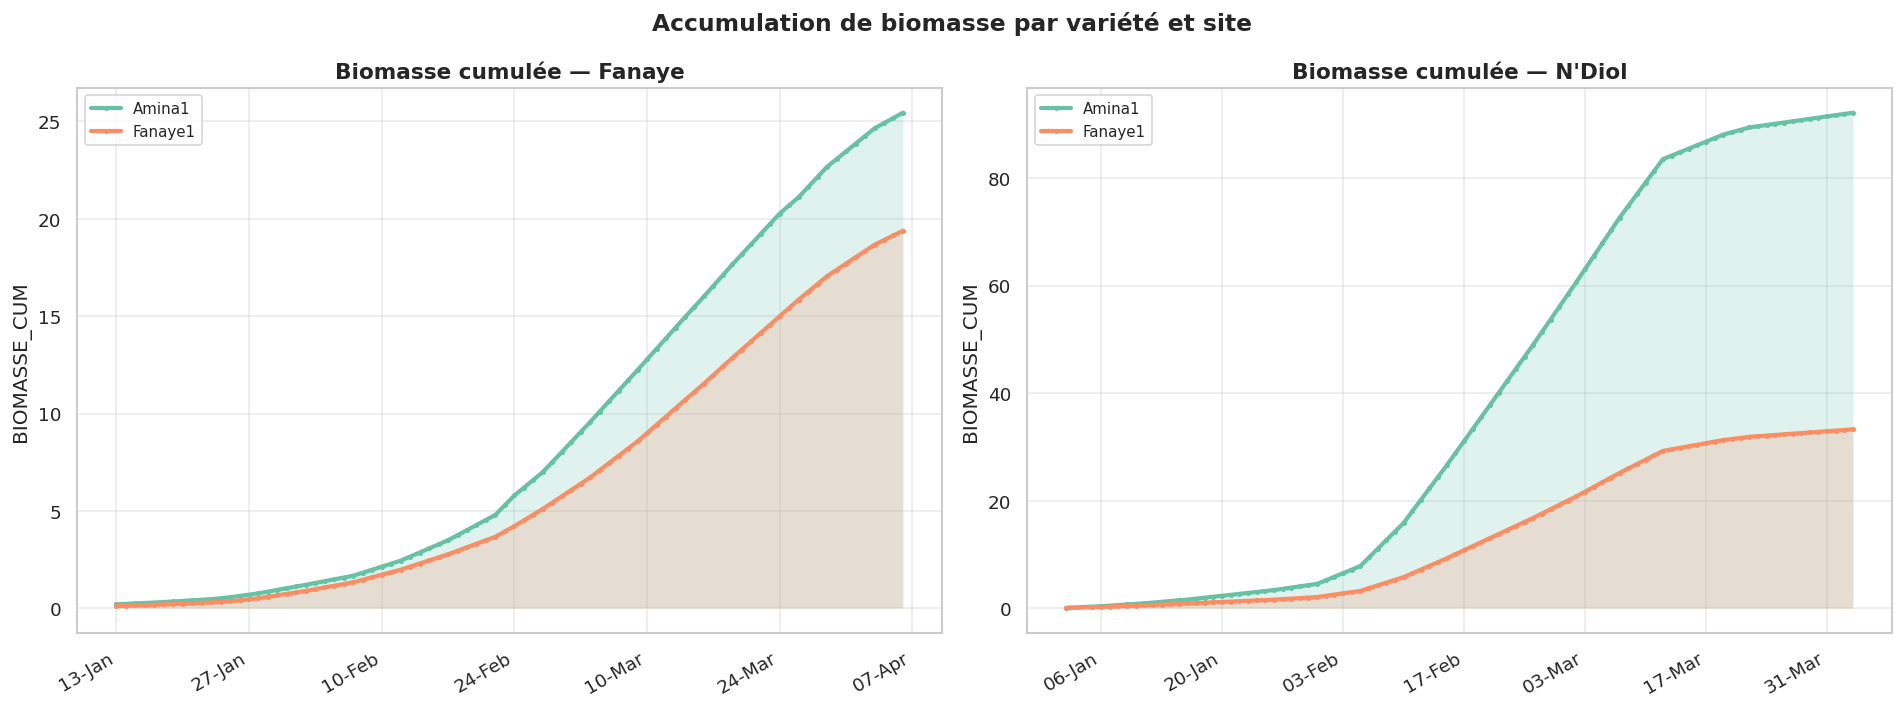

In [26]:
# ── 6.1 Courbes de biomasse cumulée ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, site in zip(axes, df['site'].unique()):
    sub = df[df['site'] == site]
    for var, grp in sub.groupby('variete'):
        ax.fill_between(grp['date'], grp['BIOMASSE_CUM'], alpha=0.2)
        ax.plot(grp['date'], grp['BIOMASSE_CUM'], linewidth=2.5, label=var, marker='o', markersize=2)
    ax.set_title(f'Biomasse cumulée — {site}', fontsize=13, fontweight='bold')
    ax.set_ylabel('BIOMASSE_CUM')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

plt.suptitle('Accumulation de biomasse par variété et site',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '6_1_bio_cumul.png', bbox_inches='tight', dpi=150)
plt.show()


# 🌾 Section 7 — Biomasse (BIOMASSE & BIOMASSE_CUM)
(Ancienne section 6, renommée après l'ajout de la section d'harmonisation)

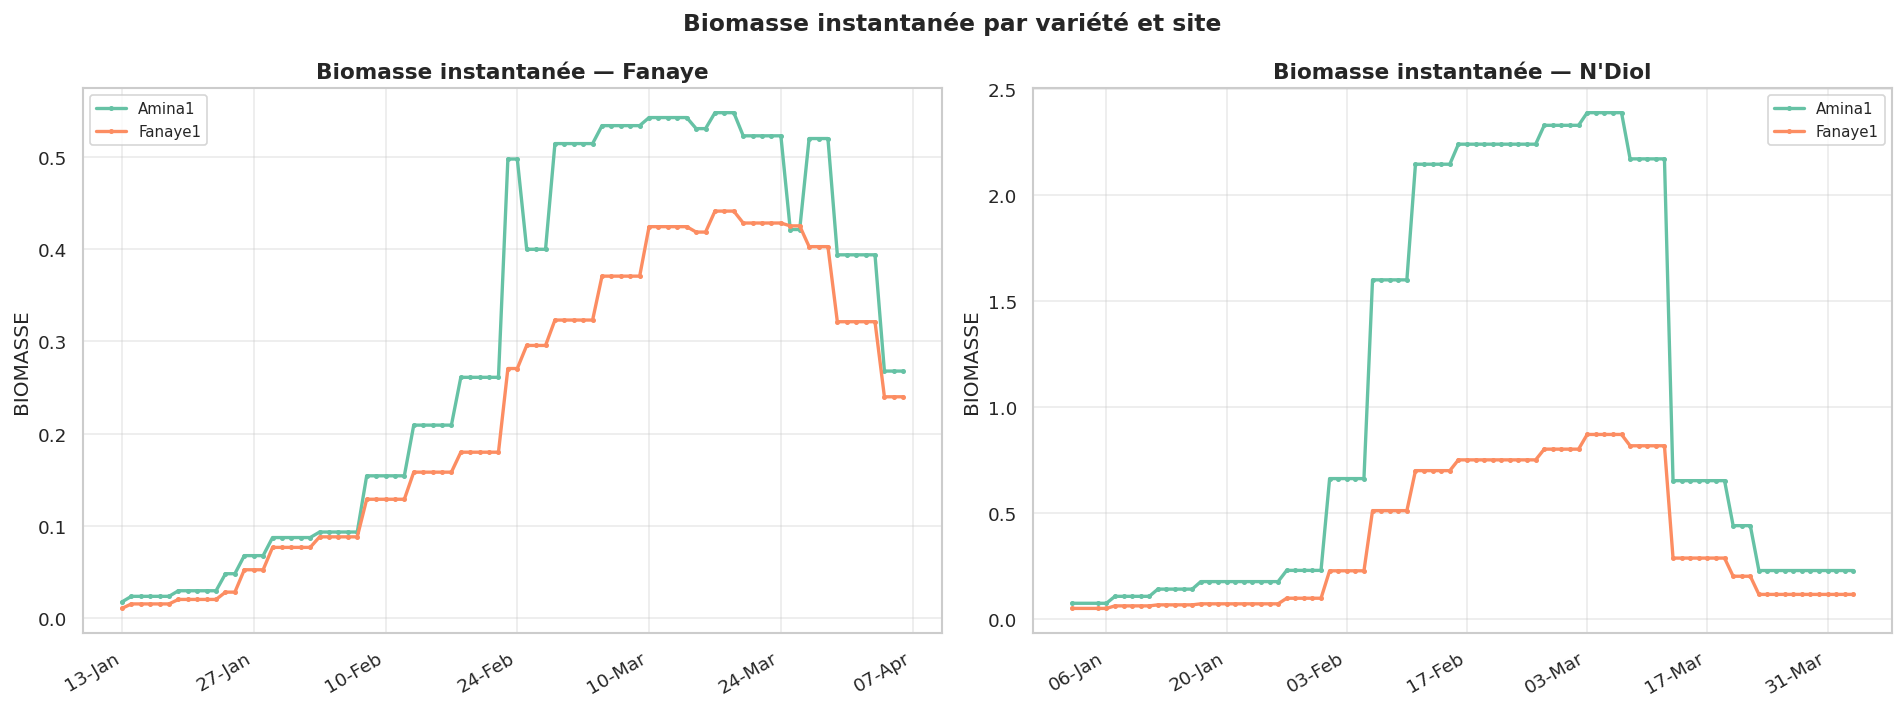

In [27]:
# ── 6.2 Biomasse instantanée ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, site in zip(axes, df['site'].unique()):
    sub = df[df['site'] == site]
    for var, grp in sub.groupby('variete'):
        ax.plot(grp['date'], grp['BIOMASSE'], linewidth=2, label=var, marker='o', markersize=2)
    ax.set_title(f'Biomasse instantanée — {site}', fontsize=13, fontweight='bold')
    ax.set_ylabel('BIOMASSE')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

plt.suptitle('Biomasse instantanée par variété et site', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '6_2_bio_instant.png', bbox_inches='tight', dpi=150)
plt.show()


=== Biomasse cumulée maximale par groupe ===
  site variete   Bio_max
Fanaye  Amina1 25.451005
Fanaye Fanaye1 19.389960
N'Diol  Amina1 92.125082
N'Diol Fanaye1 33.280892


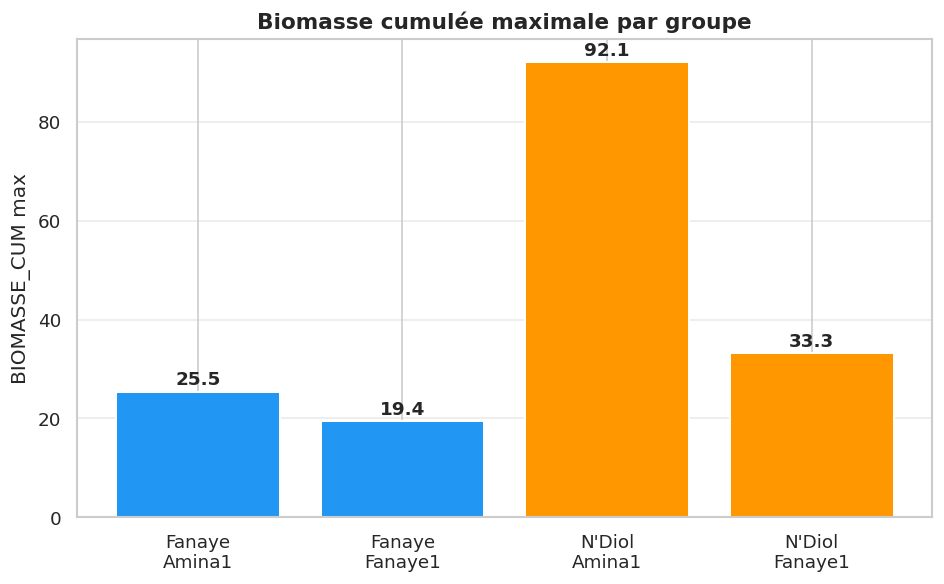

In [28]:
# ── 6.3 Biomasse maximale atteinte par groupe ─────────────────────────────────
bio_max = df.groupby(['site', 'variete'])['BIOMASSE_CUM'].max().reset_index()
bio_max.columns = ['site', 'variete', 'Bio_max']
print('=== Biomasse cumulée maximale par groupe ===')
print(bio_max.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
colors_bio = [palette[s] for s in bio_max['site']]
bars = ax.bar(bio_max['site'] + '\n' + bio_max['variete'],
              bio_max['Bio_max'], color=colors_bio, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, bio_max['Bio_max']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('Biomasse cumulée maximale par groupe', fontsize=13, fontweight='bold')
ax.set_ylabel('BIOMASSE_CUM max')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR + '6_3_bio_max.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 🔄 Section 7 — Comparaisons inter-sites & inter-variétés

# 🔄 Section 8 — Comparaisons inter-sites & inter-variétés
(Ancienne section 7, renommée après l'ajout de la section d'harmonisation)

In [ ]:
# ── 7.1 Tableau récapitulatif complet ─────────────────────────────────────────
ALL_COLS = COLS_SOL + COLS_SPEC + COLS_SAR + COLS_BIO
recap = df.groupby(['site', 'variete'])[ALL_COLS].agg(['mean', 'std']).round(3)
print('=== Tableau récapitulatif complet (moyenne ± std) ===')
display(recap)


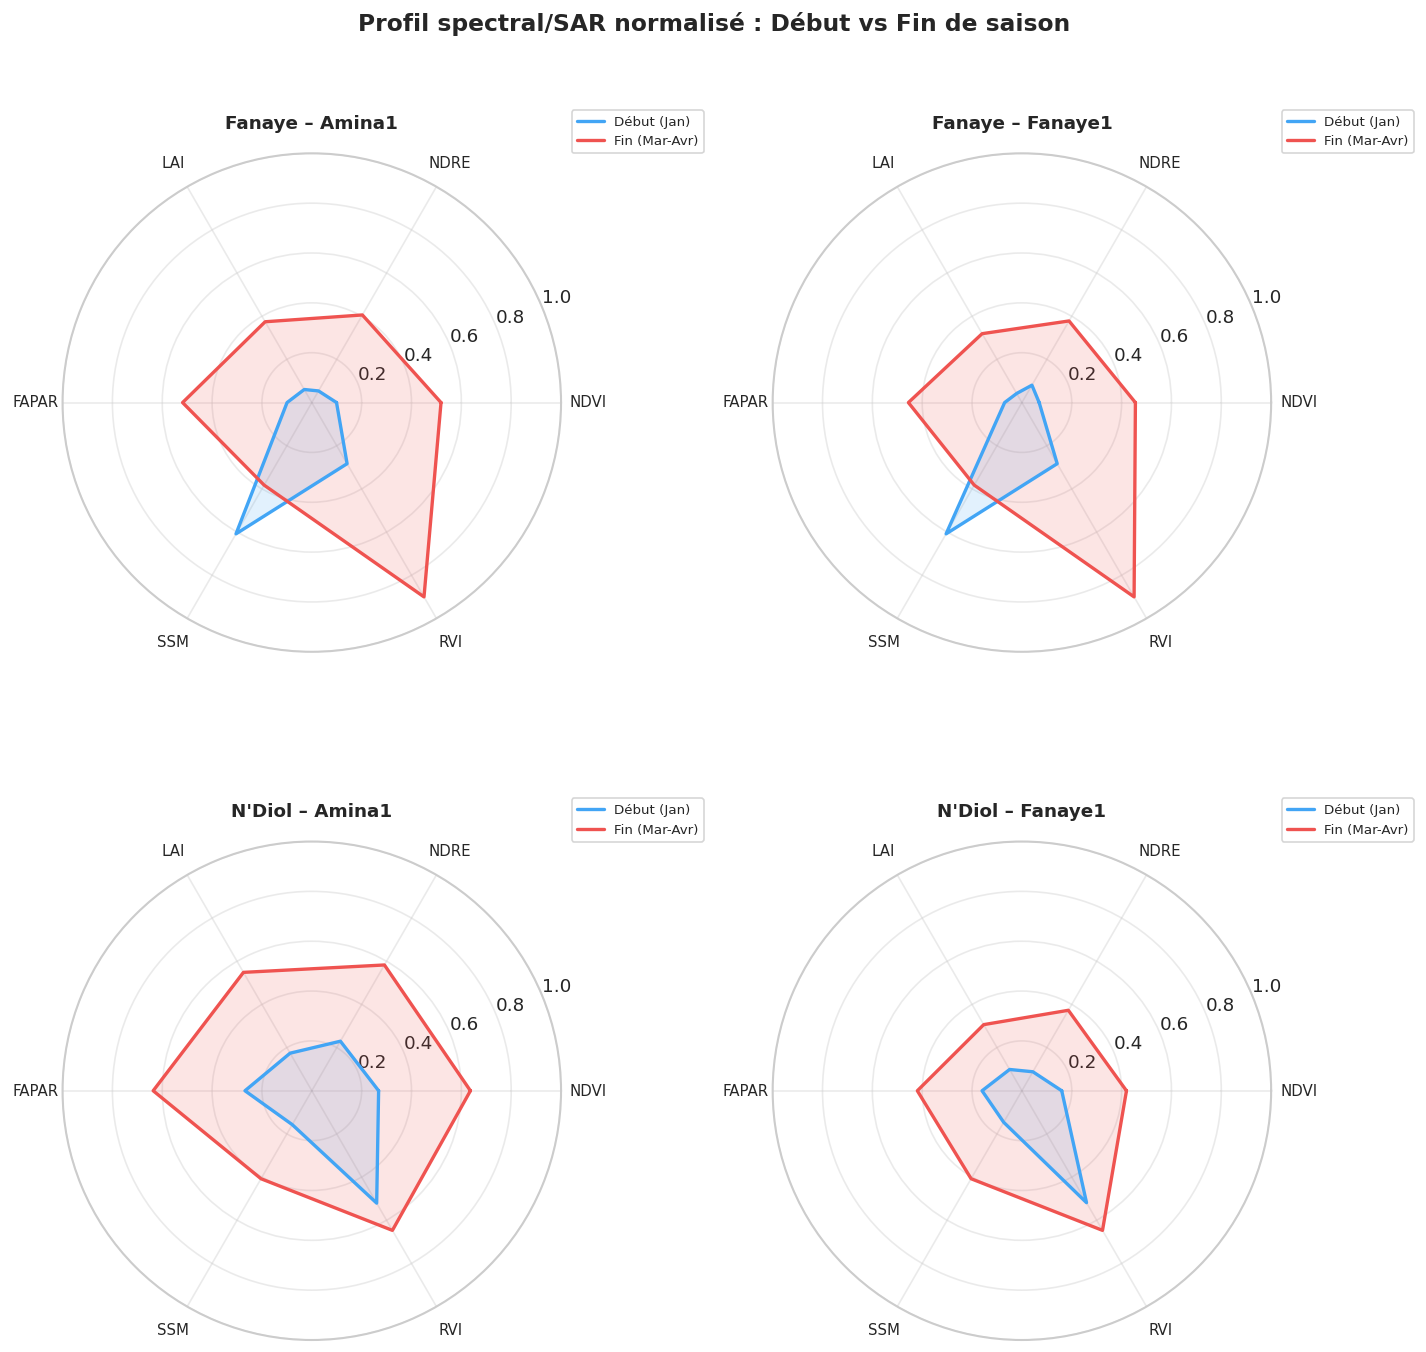

In [29]:
# ── 7.2 Radar chart : profil moyen normalisé par groupe ──────────────────────
RADAR_COLS = ['NDVI', 'NDRE', 'LAI', 'FAPAR', 'SSM', 'RVI']

fig, axes = plt.subplots(2, 2, figsize=(12, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

N = len(RADAR_COLS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

group_list = list(df.groupby(['site', 'variete']).groups.keys())

for idx, (ax, (site, var)) in enumerate(zip(axes, group_list)):
    sub = df[(df['site'] == site) & (df['variete'] == var)]
    glabel = f'{site} – {var}'
    for periode_name, color in [('Début (Jan)', '#42A5F5'), ('Fin (Mar-Avr)', '#EF5350')]:
        sub_p = sub[sub['periode'] == periode_name]
        if len(sub_p) == 0:
            continue
        vals = []
        for c in RADAR_COLS:
            col_min, col_max = df[c].min(), df[c].max()
            if col_max == col_min:
                vals.append(0)
            else:
                vals.append((sub_p[c].mean() - col_min) / (col_max - col_min))
        vals += vals[:1]
        ax.plot(angles, vals, color=color, linewidth=2, label=periode_name)
        ax.fill(angles, vals, color=color, alpha=0.15)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_COLS, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(glabel, fontsize=11, fontweight='bold', pad=15)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle('Profil spectral/SAR normalisé : Début vs Fin de saison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '7_2_radar_profil.png', bbox_inches='tight', dpi=150)
plt.show()


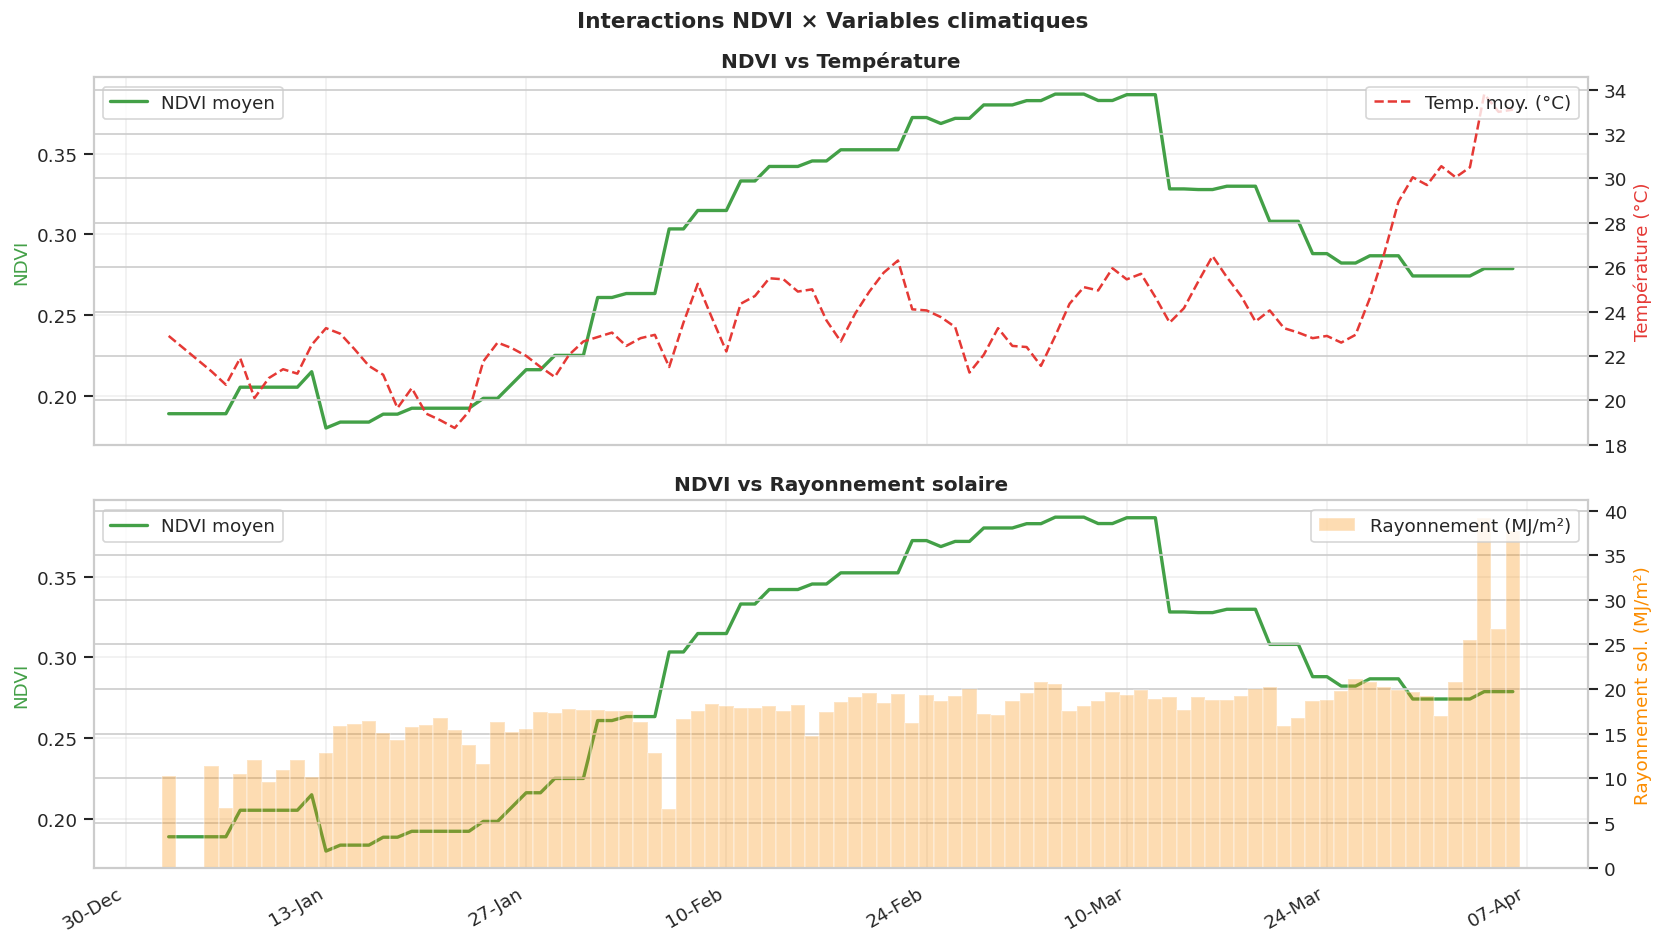

In [30]:
# ── 7.3 Évolution climatique corrélée à NDVI ─────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

df_agg = df.groupby('date').agg(
    NDVI_moy=('NDVI', 'mean'),
    temp_moy=('temp_moy_C', 'mean'),
    rad_sol=('rad_sol_MJm2', 'mean')
).reset_index()

ax1 = axes[0]
ax1.plot(df_agg['date'], df_agg['NDVI_moy'], color='#43A047', linewidth=2, label='NDVI moyen')
ax1b = ax1.twinx()
ax1b.plot(df_agg['date'], df_agg['temp_moy'], color='#E53935', linewidth=1.5,
          linestyle='--', label='Temp. moy. (°C)')
ax1.set_ylabel('NDVI', color='#43A047', fontsize=11)
ax1b.set_ylabel('Température (°C)', color='#E53935', fontsize=11)
ax1.legend(loc='upper left'); ax1b.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_title('NDVI vs Température', fontsize=12, fontweight='bold')

ax2 = axes[1]
ax2.plot(df_agg['date'], df_agg['NDVI_moy'], color='#43A047', linewidth=2, label='NDVI moyen')
ax2b = ax2.twinx()
ax2b.bar(df_agg['date'], df_agg['rad_sol'], color='#FB8C00', alpha=0.3,
         label='Rayonnement (MJ/m²)', width=1)
ax2.set_ylabel('NDVI', color='#43A047', fontsize=11)
ax2b.set_ylabel('Rayonnement sol. (MJ/m²)', color='#FB8C00', fontsize=11)
ax2.legend(loc='upper left'); ax2b.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_title('NDVI vs Rayonnement solaire', fontsize=12, fontweight='bold')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Interactions NDVI × Variables climatiques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '7_3_ndvi_climat.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 🔗 Section 8 — Matrices de corrélation & analyses croisées

# 🔗 Section 9 — Matrices de corrélation & analyses croisées
(Ancienne section 8, renommée après l'ajout de la section d'harmonisation)

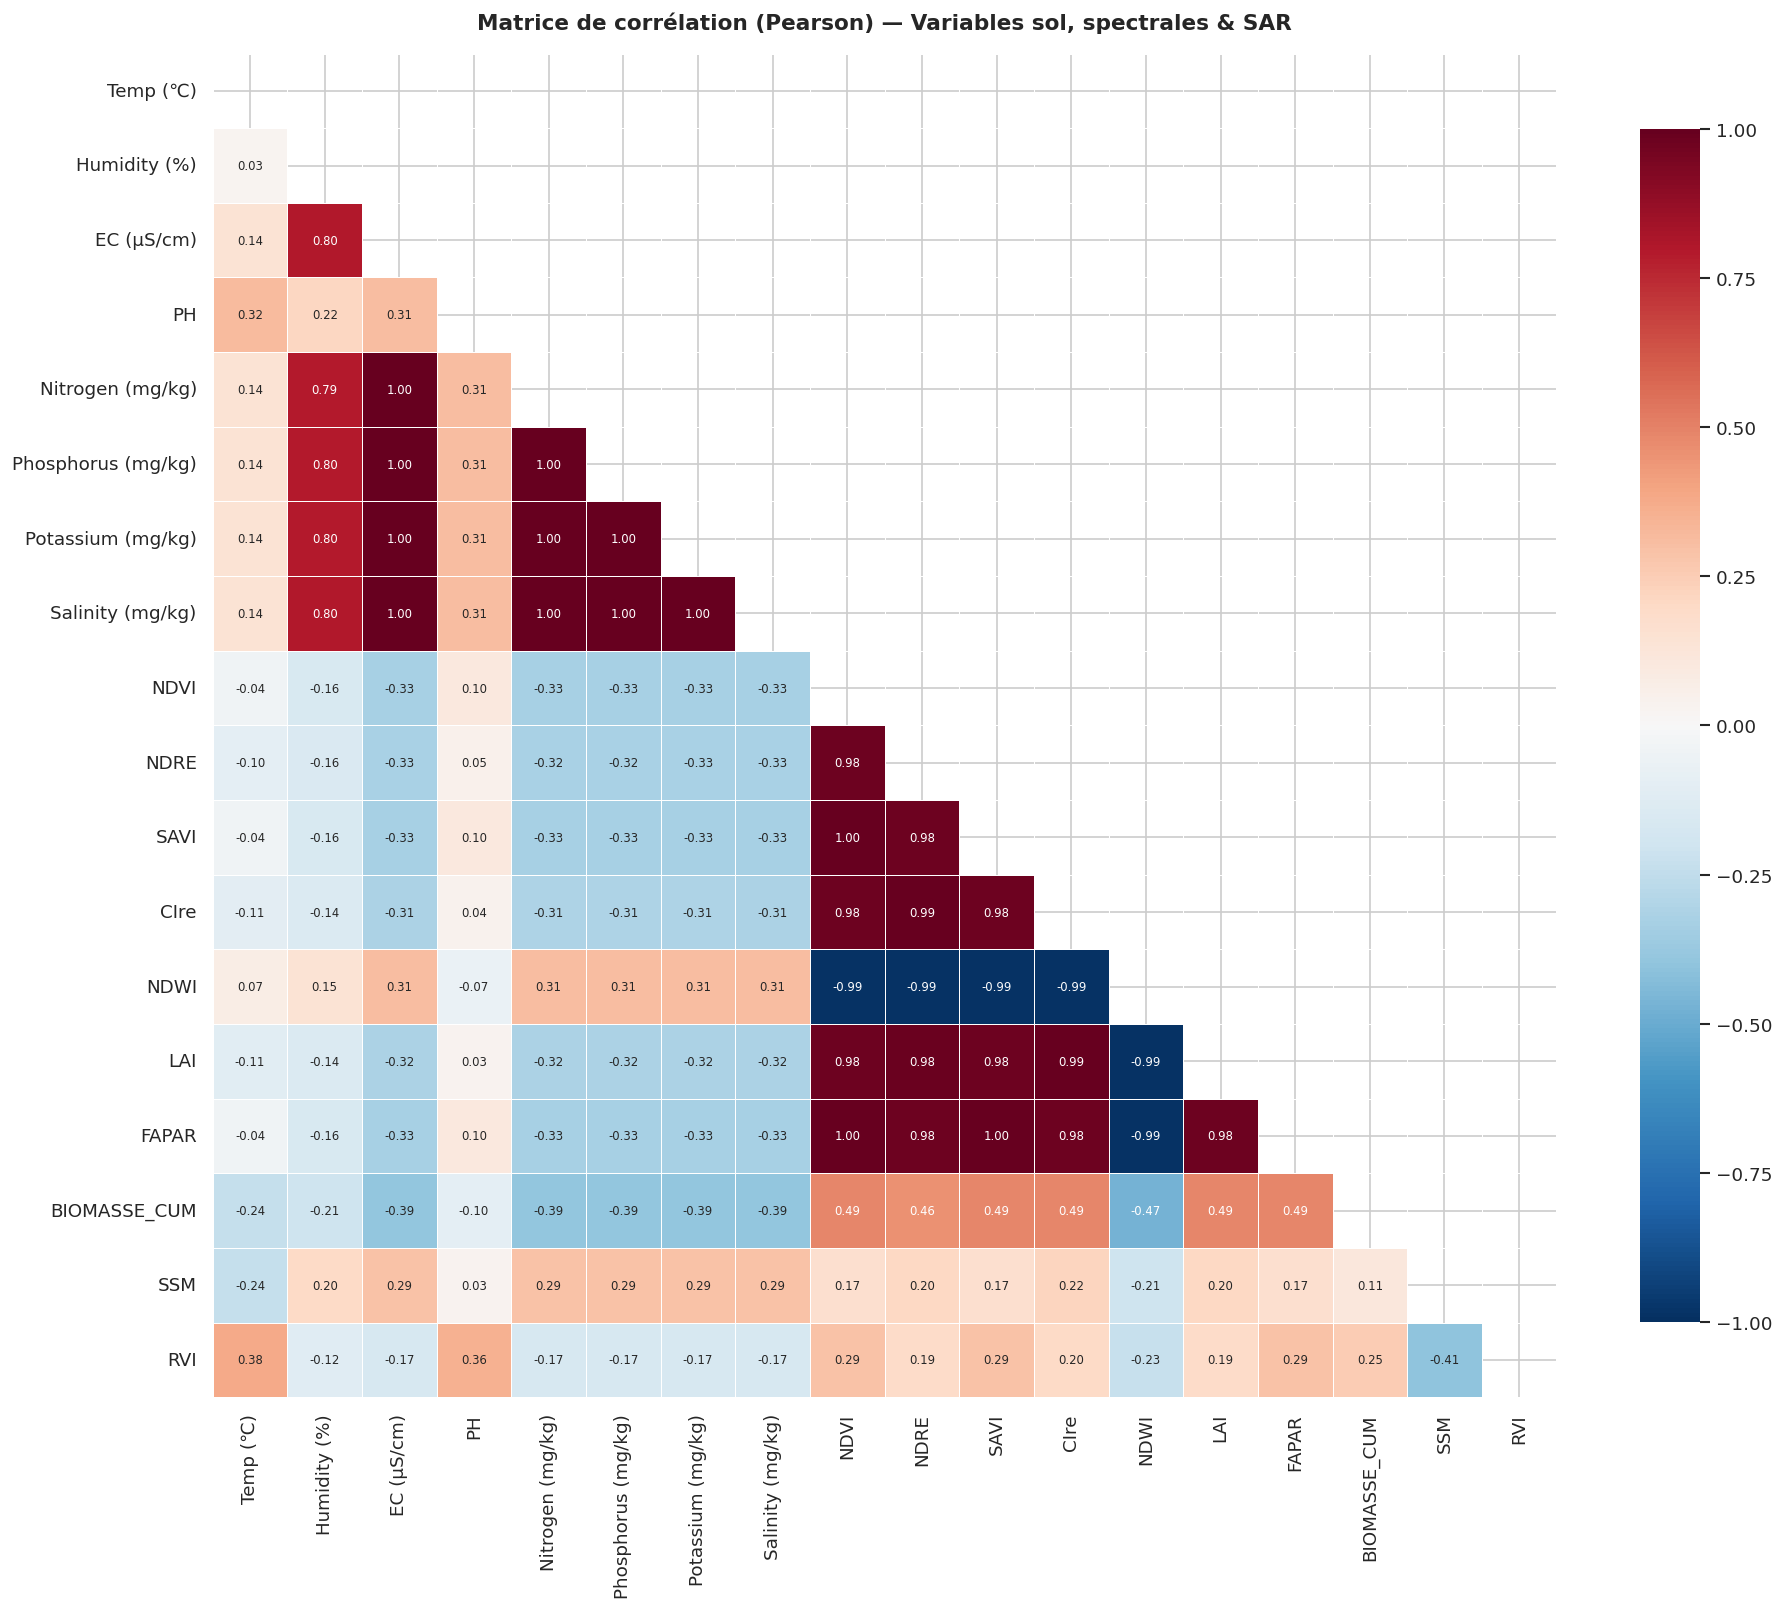

In [31]:
# ── 8.1 Matrice de corrélation globale ───────────────────────────────────────
COLS_CORR = COLS_SOL + COLS_SPEC + ['BIOMASSE_CUM', 'SSM', 'RVI']

corr_matrix = df[COLS_CORR].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Matrice de corrélation (Pearson) — Variables sol, spectrales & SAR',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUT_DIR + '8_1_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()


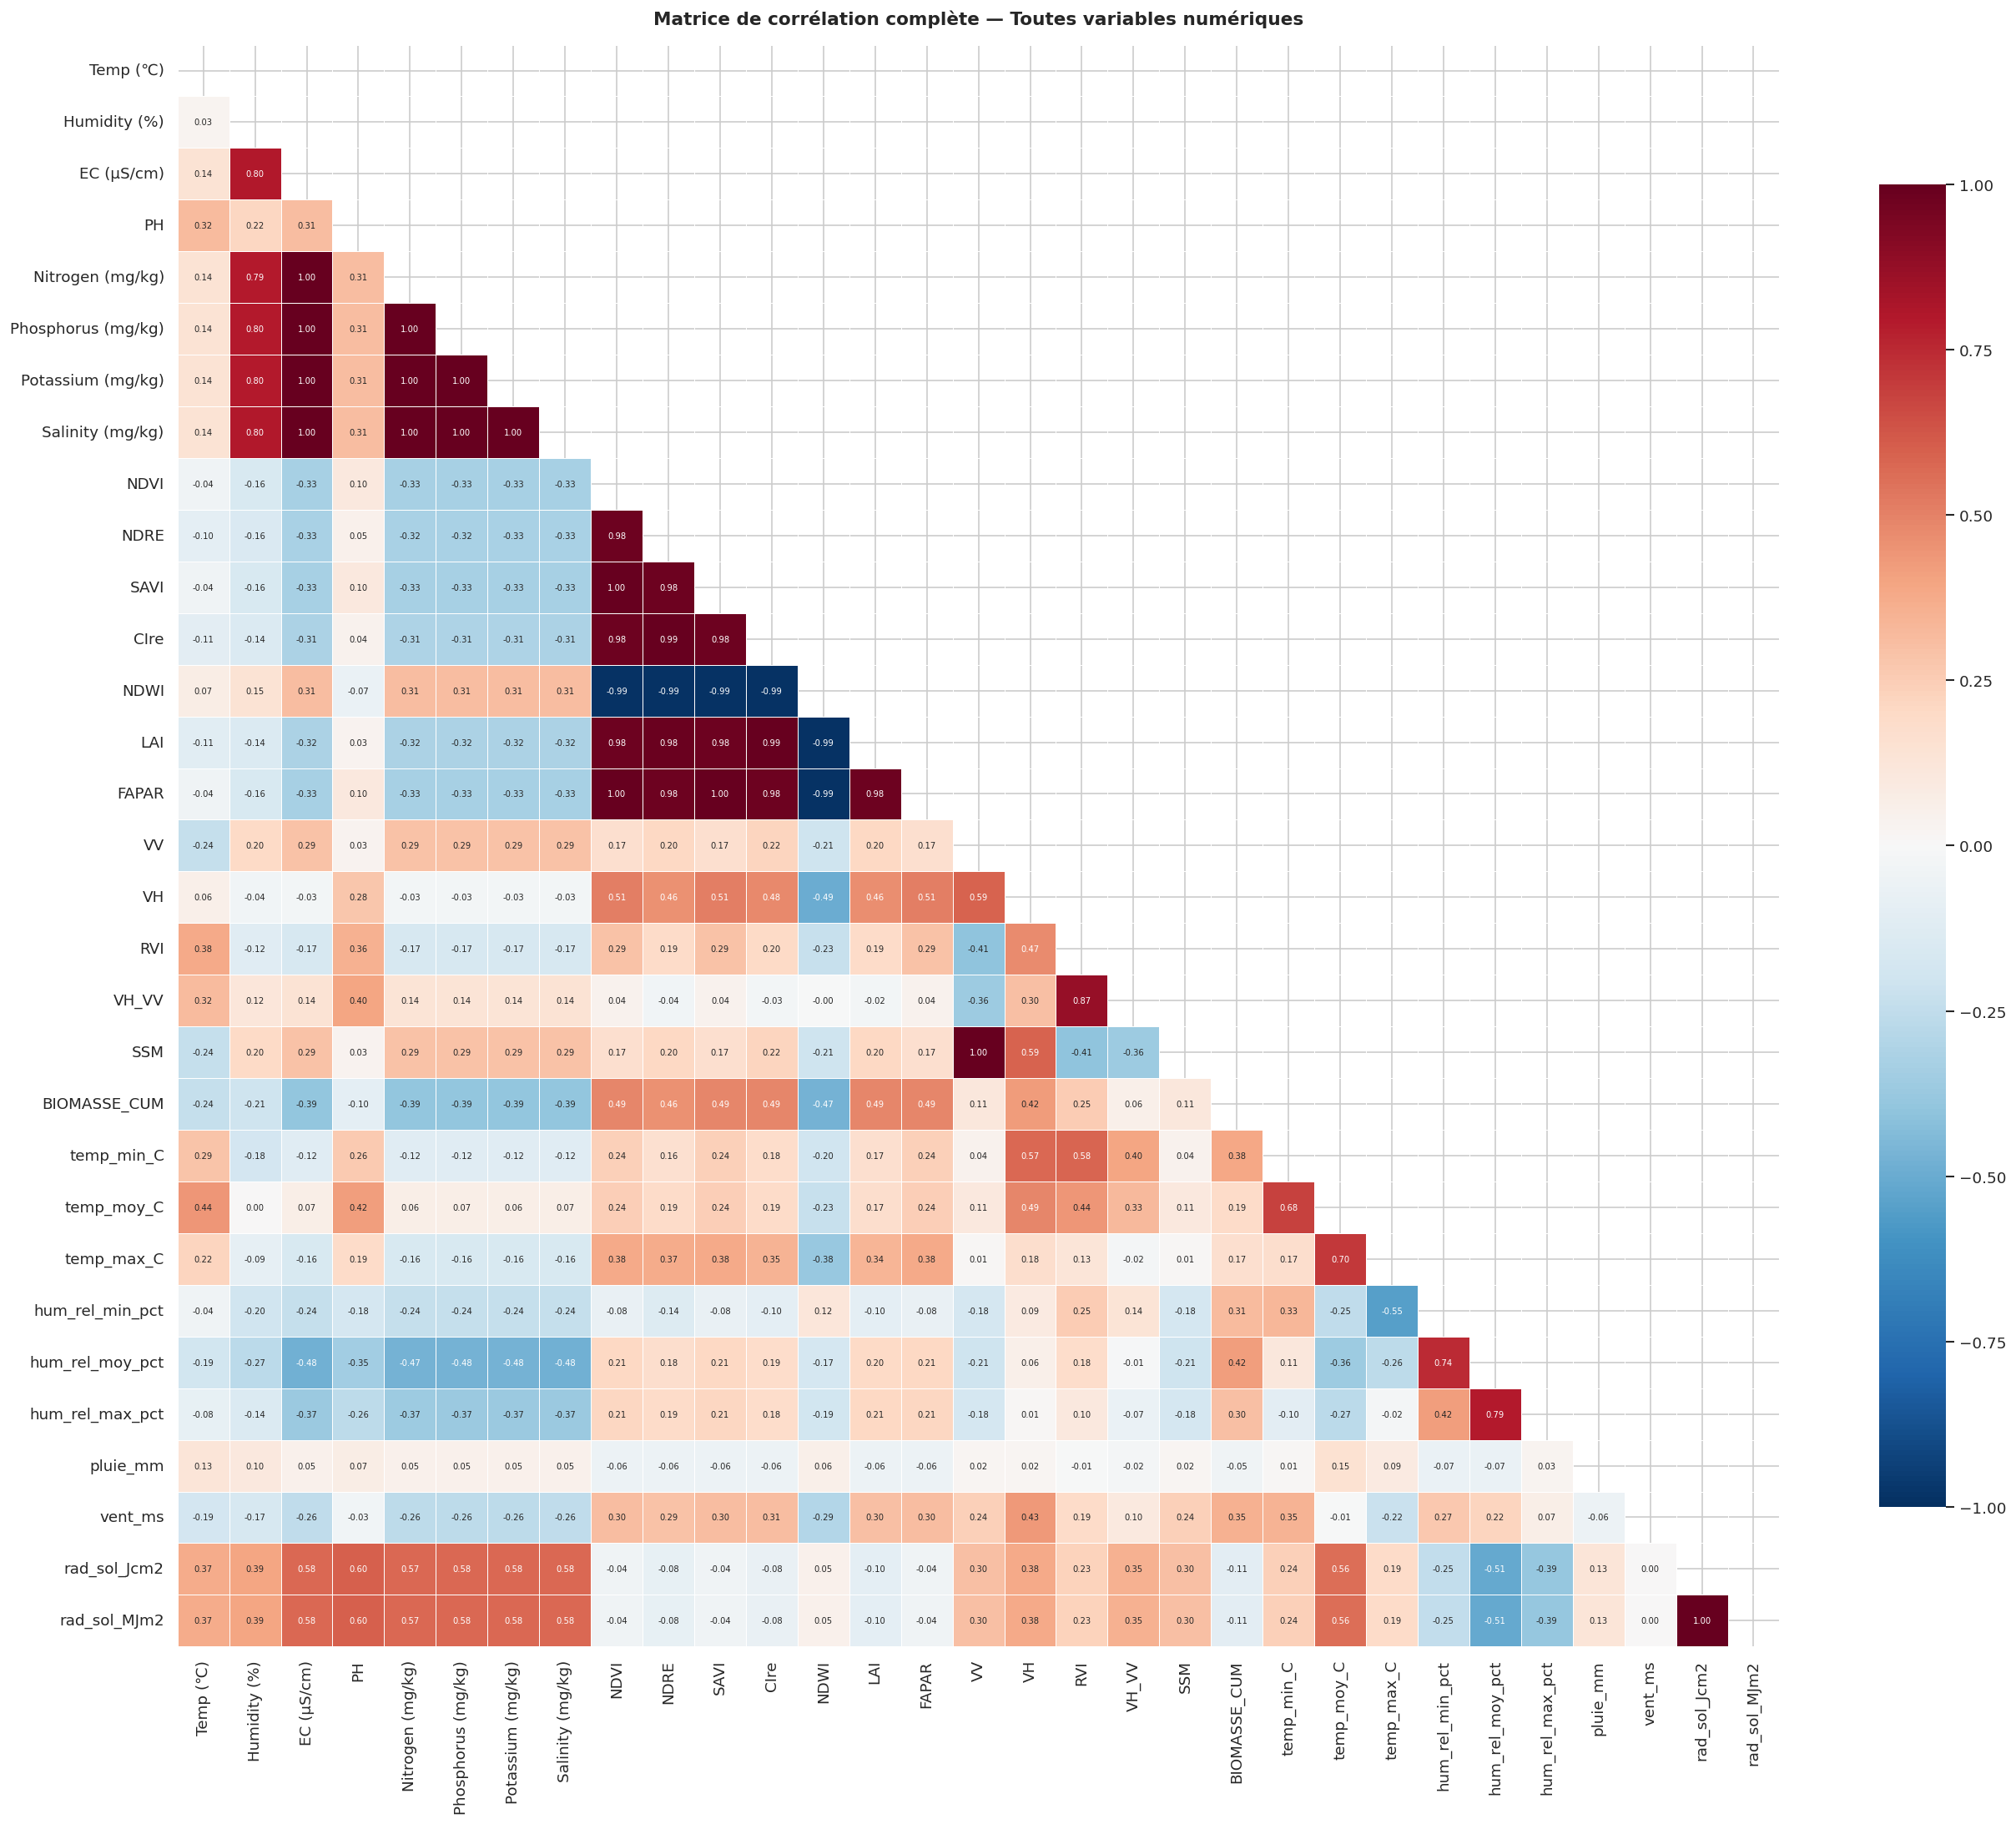

In [32]:
# ── 8.2 Matrice de corrélation complète (toutes variables numériques) ─────────
ALL_NUM = COLS_SOL + COLS_SPEC + COLS_SAR + COLS_BIO + COLS_CLIMAT
corr_full = df[ALL_NUM].corr()

fig, ax = plt.subplots(figsize=(22, 20))
mask_f = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(corr_full, mask=mask_f, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 6}, ax=ax)
ax.set_title('Matrice de corrélation complète — Toutes variables numériques',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUT_DIR + '8_1b_correlation_full.png', bbox_inches='tight', dpi=150)
plt.show()


=== Top corrélations avec NDVI ===
Salinity (mg/kg)     -0.334
EC (μS/cm)           -0.334
Potassium (mg/kg)    -0.332
Nitrogen (mg/kg)     -0.331
Phosphorus (mg/kg)   -0.331
Humidity (%)         -0.162
PH                    0.104
Temp (℃)             -0.044


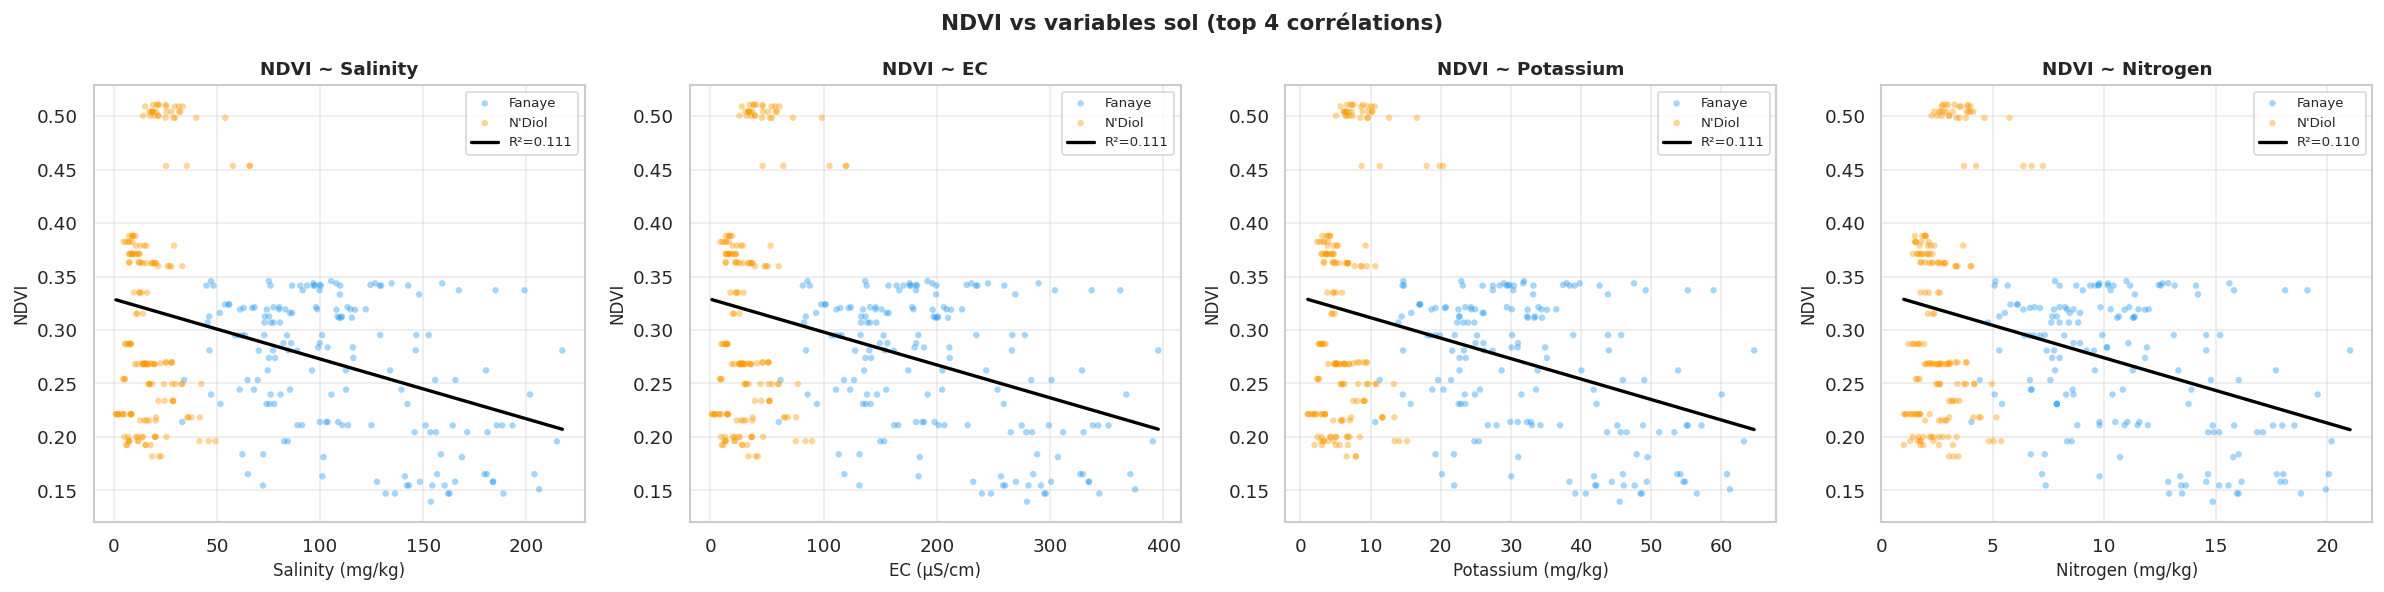

In [33]:
# ── 8.3 Top corrélations NDVI ↔ Variables sol ─────────────────────────────────
print('=== Top corrélations avec NDVI ===')
corr_ndvi = df[COLS_SOL + ['NDVI']].corr()['NDVI'].drop('NDVI').sort_values(key=abs, ascending=False)
print(corr_ndvi.round(3).to_string())

top4 = corr_ndvi.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, col in zip(axes, top4):
    for site, grp in df.groupby('site'):
        ax.scatter(grp[col], grp['NDVI'], c=palette[site],
                   alpha=0.4, s=15, label=site, edgecolors='none')
    sub2 = df[[col, 'NDVI']].dropna()
    m, b, r, p, _ = stats.linregress(sub2[col], sub2['NDVI'])
    x_line = np.linspace(sub2[col].min(), sub2[col].max(), 100)
    ax.plot(x_line, m*x_line + b, 'k-', linewidth=2, label=f'R²={r**2:.3f}')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('NDVI', fontsize=10)
    ax.set_title(f'NDVI ~ {col.split(" ")[0]}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle('NDVI vs variables sol (top 4 corrélations)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '8_2_NDVI_sol_scatter.png', bbox_inches='tight', dpi=150)
plt.show()


=== Top corrélations avec BIOMASSE_CUM ===
CIre                  0.491
NDVI                  0.486
FAPAR                 0.486
SAVI                  0.486
LAI                   0.485
NDWI                 -0.473
NDRE                  0.459
VH                    0.422
hum_rel_moy_pct       0.420
Salinity (mg/kg)     -0.394
EC (μS/cm)           -0.394
Potassium (mg/kg)    -0.393
Phosphorus (mg/kg)   -0.392
Nitrogen (mg/kg)     -0.391
temp_min_C            0.384
vent_ms               0.354
hum_rel_min_pct       0.313
hum_rel_max_pct       0.300
RVI                   0.251
Temp (℃)             -0.242
Humidity (%)         -0.206
temp_moy_C            0.190
temp_max_C            0.166
SSM                   0.111
VV                    0.111
rad_sol_MJm2         -0.109
rad_sol_Jcm2         -0.109
PH                   -0.100
VH_VV                 0.057
pluie_mm             -0.047


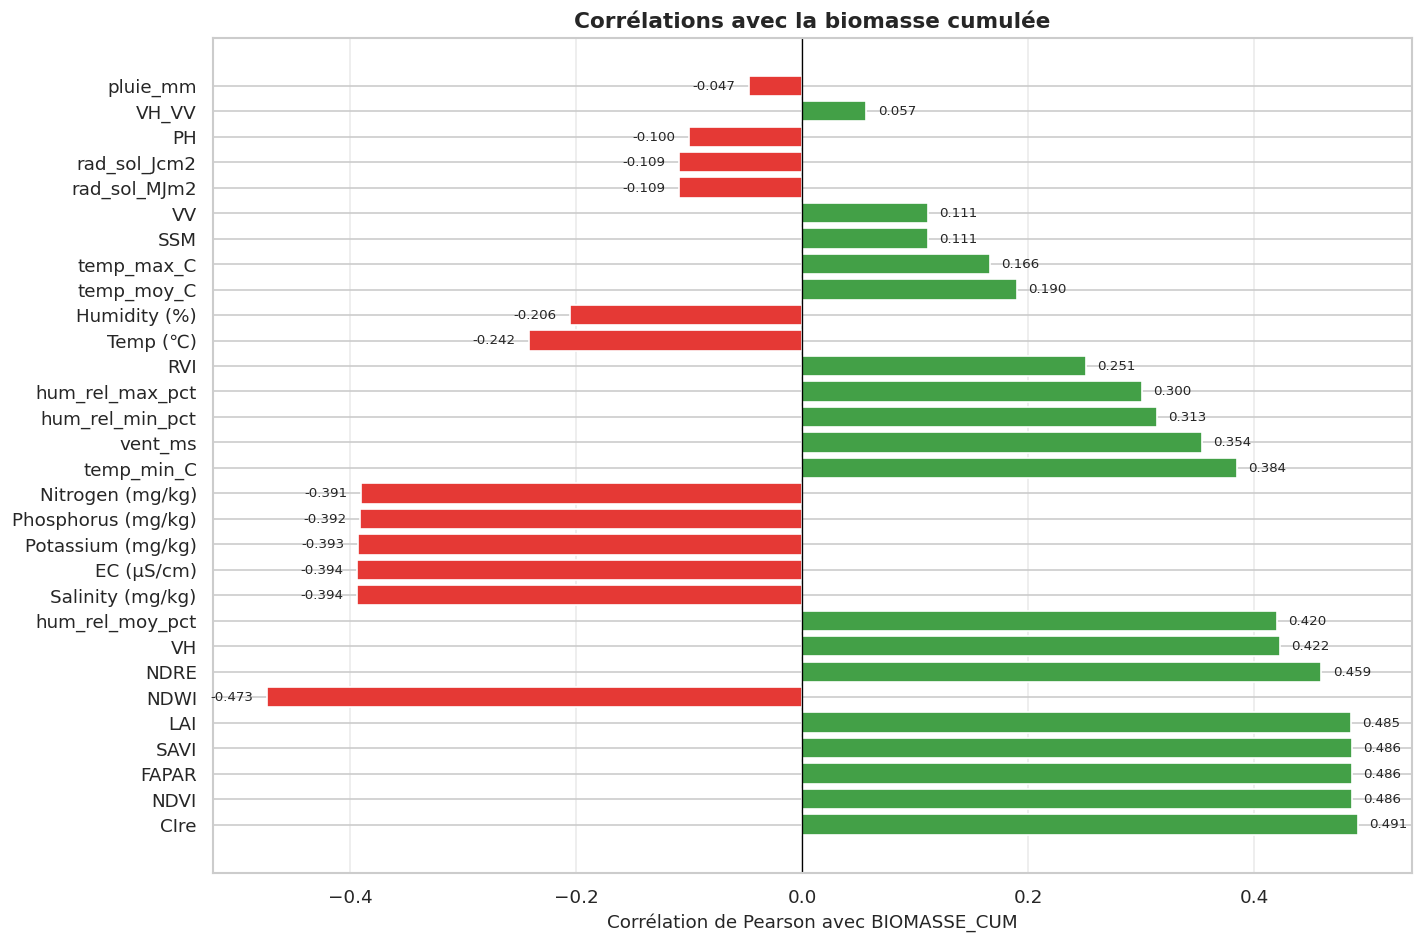

In [34]:
# ── 8.4 Corrélations Biomasse ↔ Toutes variables ──────────────────────────────
print('=== Top corrélations avec BIOMASSE_CUM ===')
corr_bio = df[COLS_SOL + COLS_SPEC + COLS_SAR + COLS_CLIMAT + ['BIOMASSE_CUM']].corr()['BIOMASSE_CUM']
corr_bio = corr_bio.drop('BIOMASSE_CUM').sort_values(key=abs, ascending=False)
print(corr_bio.round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 8))
colors_c = ['#E53935' if v < 0 else '#43A047' for v in corr_bio.values]
bars = ax.barh(corr_bio.index, corr_bio.values, color=colors_c, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Corrélation de Pearson avec BIOMASSE_CUM', fontsize=11)
ax.set_title('Corrélations avec la biomasse cumulée', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
for bar, val in zip(bars, corr_bio.values):
    x_pos = val + 0.01 if val >= 0 else val - 0.05
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR + '8_3_bio_correlations.png', bbox_inches='tight', dpi=150)
plt.show()


=== Corrélations NDVI ~ Variables climatiques ===
temp_max_C         0.380
vent_ms            0.305
temp_moy_C         0.243
temp_min_C         0.238
hum_rel_max_pct    0.211
hum_rel_moy_pct    0.206
hum_rel_min_pct   -0.078
pluie_mm          -0.056
rad_sol_MJm2      -0.042
rad_sol_Jcm2      -0.042


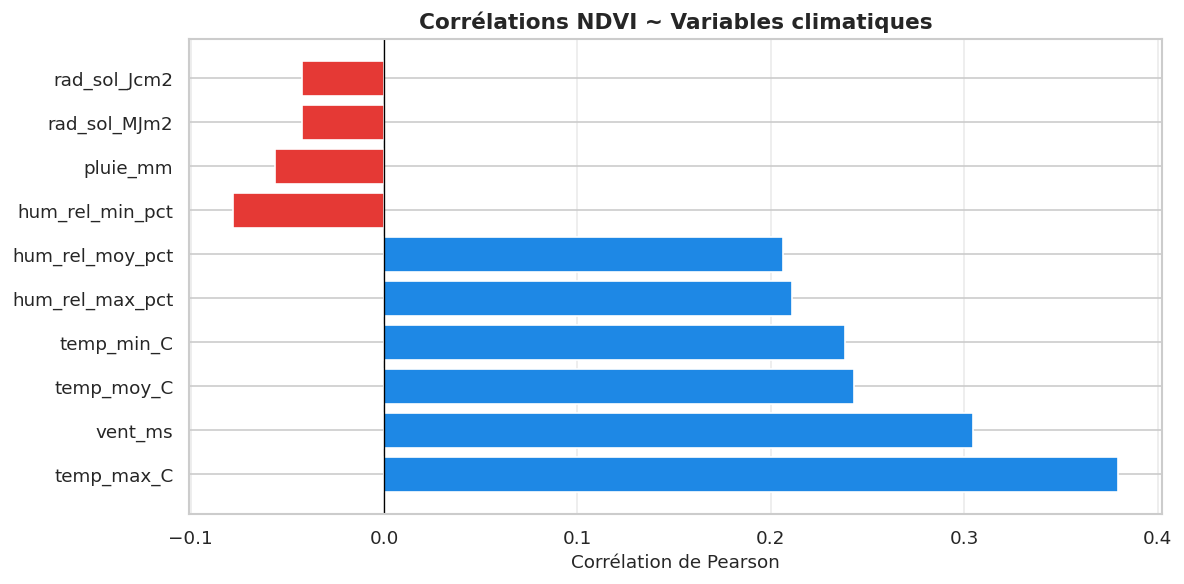

In [35]:
# ── 8.5 Corrélations NDVI ↔ Variables climatiques ────────────────────────────
print('=== Corrélations NDVI ~ Variables climatiques ===')
corr_clim = df[COLS_CLIMAT + ['NDVI']].corr()['NDVI'].drop('NDVI').sort_values(key=abs, ascending=False)
print(corr_clim.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors_clim = ['#E53935' if v < 0 else '#1E88E5' for v in corr_clim.values]
ax.barh(corr_clim.index, corr_clim.values, color=colors_clim, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Corrélation de Pearson', fontsize=11)
ax.set_title('Corrélations NDVI ~ Variables climatiques', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR + '8_5_NDVI_climat_corr.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 💾 Section 9 — Export résultats

# 💾 Section 10 — Export résultats
(Ancienne section 9, renommée après l'ajout de la section d'harmonisation)

In [ ]:
# ── 9.1 Export CSV résumé statistique ────────────────────────────────────────
summary = df.groupby(['site', 'variete', 'periode'])[COLS_SOL + COLS_SPEC + COLS_SAR + COLS_BIO + COLS_CLIMAT]\
    .agg(['mean', 'std', 'min', 'max']).round(4)
summary.to_csv(OUT_DIR + 'resume_statistique.csv', encoding='utf-8-sig')
print('✅ Résumé statistique exporté → resume_statistique.csv')

# ── 9.2 Export matrice corrélations ──────────────────────────────────────────
corr_full.round(4).to_csv(OUT_DIR + 'matrice_correlations.csv', encoding='utf-8-sig')
print('✅ Matrice corrélations exportée → matrice_correlations.csv')

# ── 9.3 Export base enrichie ─────────────────────────────────────────────────
df.to_csv(OUT_DIR + 'base_final_enrichie.csv', index=False, encoding='utf-8-sig')
print('✅ Base enrichie (+ colonne periode) exportée → base_final_enrichie.csv')

# ── 9.4 Téléchargement depuis Colab ──────────────────────────────────────────
from google.colab import files
for f in ['resume_statistique.csv', 'matrice_correlations.csv', 'base_final_enrichie.csv']:
    files.download(OUT_DIR + f)
print('\n📥 Fichiers CSV téléchargés.')


In [ ]:
# ── 9.5 Récapitulatif des figures générées ────────────────────────────────────
import os
figs = sorted([f for f in os.listdir(OUT_DIR) if f.endswith('.png')])
print(f'=== {len(figs)} figures exportées dans {OUT_DIR} ===')
for f in figs:
    print(f'   📊 {f}')


---
## ✅ Récapitulatif des analyses

| Section | Analyse | Fichier |
|---------|---------|---------|
| 2 | Distribution TYPE_blé | `2_4_type_ble.png` |
| 3 | Distributions sol | `3_1_distributions_sol.png` |
| 3 | Évolution temporelle sol | `3_2_evolution_sol.png` |
| 3 | Boxplots sol × variété | `3_3_boxplots_sol.png` |
| 4 | Indices spectraux temporels | `4_1_evolution_spectral.png` |
| 4 | Courbe NDVI + stades phénologiques | `4_2_ndvi_croissance.png` |
| 4 | Profil spectral par période | `4_3_profil_spectral.png` |
| 4 | Boxplots spectraux | `4_4_boxplots_spectral.png` |
| 5 | SAR (VV, VH, RVI, SSM) | `5_1_evolution_SAR.png` |
| 5 | Scatter VV vs VH | `5_2_scatter_VVVH.png` |
| 5 | Validation SSM vs Humidity | `5_3_SSM_validation.png` |
| 5 | Évolution climatique | `5_5_evolution_climatique.png` |
| 5 | Amplitude thermique | `5_6_amplitude_thermique.png` |
| 6 | Biomasse cumulée | `6_1_bio_cumul.png` |
| 6 | Biomasse instantanée | `6_2_bio_instant.png` |
| 7 | Radar profil normalisé | `7_2_radar_profil.png` |
| 7 | NDVI × Climatique | `7_3_ndvi_climat.png` |
| 8 | Matrice corrélation sol+spectral | `8_1_correlation_matrix.png` |
| 8 | Matrice corrélation complète | `8_1b_correlation_full.png` |
| 8 | NDVI ~ variables sol | `8_2_NDVI_sol_scatter.png` |
| 8 | BIOMASSE_CUM ~ tout | `8_3_bio_correlations.png` |
| 8 | NDVI ~ climatique | `8_5_NDVI_climat_corr.png` |

> 🔜 **Suite** : Notebook 02 — Assimilation de données & modélisation


# ✅ Récapitulatif des analyses
(Sections mises à jour après l'ajout de la section d'harmonisation)